In [9]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import ast

In [10]:
path = "/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/*.log"
log_file = glob.glob(path)
log_file

['/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker1.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker3.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker2.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker6.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker7.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker5.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker4.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker19.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker25.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker24.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_run_1_log/walker18.log',
 '/Users/sahananarasimha/protomodels/log_files_from_clip/bsm_

In [11]:
def read_log_file(file_path):
    
    step_list,muhat_list,proto_list,accratio_list = [],[],[],[]

    step_pattern = re.compile(r'\[randomWalker.*\] Step (\d+) begins')
    muhat_pattern = re.compile(r'with muhat ([\d.]+)')
    proto_pattern = re.compile(r"Protomodel: ({.*})")
    accratio_pattern = re.compile(r"Acceptance ratio (\d+(\.\d+)?)")

    current_step = None
    current_muhat = np.nan
    current_proto = {}
    current_accratio = 0.0
    ctr = 0
    with open(file_path, 'r') as file:
        for line in file:
            step_match = step_pattern.search(line)
            if step_match:
                if current_step:
                    step_list.append(current_step)
                    muhat_list.append(current_muhat)
                    proto_list.append(current_proto)
                    accratio_list.append(current_accratio)

                current_step = int(step_match.group(1))
                #if current_step > 1400: print(current_step)
                current_muhat = np.nan
                current_proto = {}
                current_accratio = 0.0

            muhat_match = muhat_pattern.search(line)
            proto_match = proto_pattern.search(line)
            accratio_match = accratio_pattern.search(line)
            if muhat_match:
                try:
                    current_muhat = float(muhat_match.group(1))
                except ValueError:
                    current_muhat = np.nan

            if proto_match:
                current_proto = eval(proto_match.group(1))

            if accratio_match:
                current_accratio = float(accratio_match.group(1))

        if current_step:
            step_list.append(current_step)
            muhat_list.append(current_muhat)
            proto_list.append(current_proto)
            accratio_list.append(current_accratio)
    
    return step_list, muhat_list, proto_list, accratio_list

In [12]:
def get_proto_par(proto):
    
    accepted = proto['Accepted']
    K = proto['K']
    TL = proto['TL']
    return accepted, K, TL

def get_all_proto(step_list, proto_list):
    acc_list, K_list, TL_list = [],[],[]
    for proto in proto_list:
        if proto == {}: continue
        acc, K, TL = get_proto_par(proto)
        acc_list.append(acc)
        K_list.append(K)
        TL_list.append(TL)
    
    K_list = plot_trace_K(step_list, acc_list, K_list, TL_list)
    return K_list

In [17]:
def plot_trace_K(step_list, accepted, K, TL):
    K_list,TL_list = [],[]
    #step_list  = step_list[:-1]
    ind_acc = 0
    
    for i,acc in enumerate(accepted):
        if acc == 0:
            ind_acc = i
            if K[i] is not None:
                K_list.append(K[i])
                TL_list.append(TL[i])
            else: 
                ind_acc = i-1
                K_list.append(K[i-1])
                TL_list.append(TL[i-1])
        else:
            if K[ind_acc] is not None: 
                K_list.append(K[ind_acc])
                TL_list.append(TL[ind_acc])
            else: 
                K_list.append(K[i-1])
                TL_list.append(TL[i-1])
    
    if len(step_list) != len(K_list):
        if len(step_list) < len(K_list): step_list.append(step_list[-1]+1)
        else: step_list = step_list[:-1]
    
    #print(K_list[6607:6615])
    #print(TL_list[6607:6615])
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    ax[0].plot(step_list, K_list, label='K')
    ax[1].plot(step_list, TL_list, label='TL')
    ax[0].set_xlabel('step')
    ax[0].set_ylabel('K')
    ax[1].set_xlabel('step')
    ax[1].set_ylabel('TL')
    plt.show()
    return K_list

def plot_num_of_par(step_list, proto_list, K_list):
    step_list = step_list[:-1]
    num_list = []
    ind_acc = 0
    for i,proto in enumerate(proto_list):
        if proto == {}: continue
        acc = proto['Accepted']
        num_par = len(proto['masses'].keys())
        K = proto['K']
        if acc == 0:   
            num_list.append(num_par)
            ind_acc =i
        else:
            proto_prev = proto_list[ind_acc]
            num_par = len(proto_prev['masses'].keys())
            num_list.append(num_par)

    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
    ax1.plot(step_list, num_list, color='b', label='num', alpha=0.5)
    ax1.set_xlabel('step')
    ax1.set_ylabel('Num of par')

    ax2 = ax1.twinx()
    ax2.plot(step_list, K_list, color='r', label='K', alpha=0.4)
    ax2.set_ylabel('K')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

def plot_mass_of_lsp(step_list, proto_list):
    #step_list = step_list[:-1]
    mass_list,TL_list = [],[]
    ind_acc = 0
    for i,proto in enumerate(proto_list):
        if proto == {}: continue
        acc = proto['Accepted']
        mass_lsp = float(proto['masses'][1000022])
        TL = proto['TL']
        if acc == 0:   
            mass_list.append(mass_lsp)
            TL_list.append(TL)
            ind_acc =i
        else:
            proto_prev = proto_list[ind_acc]
            mass_lsp = float(proto_prev['masses'][1000022])
            TL = proto_prev['TL']
            mass_list.append(mass_lsp)
            TL_list.append(TL)
    
    if len(step_list) != len(mass_list):
        if len(step_list) < len(mass_list): step_list.append(step_list[-1]+1)
        else: step_list = step_list[:-1]

    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
    ax1.plot(step_list, mass_list, color='b', label='num', alpha=0.6)
    ax1.set_xlabel('step')
    ax1.set_ylabel('Mass')
    
    ax2 = ax1.twinx()
    ax2.plot(step_list, TL_list, color='r', label='TL', alpha=0.4)
    ax2.set_ylabel('TL')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.show()

def plot_accratio(step_list, proto_list, accratio_list):
    #step_list = step_list[:-1]
    K_list = []
    accr_list = []
    ind_acc = 0
    for i,proto in enumerate(proto_list):
        if proto == {}: continue
        acc = proto['Accepted']
        K = proto['K']
        if acc == 0:   
            accratio = accratio_list[i]
            accr_list.append(accratio)
            K = proto['K']
            K_list.append(K)
            ind_acc =i
        else:
            if ind_acc == 0: 
                accr_list.append(0)
                K_list.append(-20)
                continue
            accratio = accratio_list[ind_acc]
            K = proto_list[ind_acc]['K']         
            accr_list.append(accratio)
            K_list.append(K)
    
    if len(step_list) != len(accr_list):
        if len(step_list) < len(accr_list): step_list.append(step_list[-1]+1)
        else: step_list = step_list[:-1]

    if not np.any(accr_list):
        #print(not np.any(accr_list))
        print(f"non zeros {np.where(accr_list != 0)[0]}")
        print(f"All acceptance ratio zero. Total Steps {step_list[-1]}")
        return
        
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
    ax1.plot(step_list, accr_list, color='b', label='accr', alpha=0.5)
    ax1.set_xlabel('step')
    ax1.set_ylabel('Acc ratio')
    ax1.set_yscale('log')

    ax2 = ax1.twinx()
    ax2.plot(step_list, K_list, color='r', label='K', alpha=0.4)
    ax2.set_ylabel('K')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

def plot_full_accratio(step_list, proto_list, accratio_list):

    #step_list = step_list[:-1]
    K_list = []
    accr_list,new_step_list = [],[]
    ind_acc = 0
    for i,proto in enumerate(proto_list):
        if proto == {}: continue
        acc = proto['Accepted']
        #K = proto['K']
        if acc ==0:   
            accratio = accratio_list[i]
            accr_list.append(accratio)
            new_step_list.append(step_list[i])
            #K = proto['K']
            #K_list.append(K)
            #ind_acc =i
        
    
    if len(new_step_list) != len(accr_list):
        if len(new_step_list) < len(accr_list): step_list.append(step_list[-1]+1)
        else: new_step_list = new_step_list[:-1]
    '''
    if not np.any(accr_list):
        #print(not np.any(accr_list))
        print(f"non zeros {np.where(accr_list != 0)[0]}")
        print(f"All acceptance ratio zero. Total Steps {step_list[-1]}")
        return
    '''
    
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
    ax1.plot(new_step_list, accr_list, color='b', label='accr', alpha=0.5)
    ax1.set_xlabel('step')
    ax1.set_ylabel('Acc ratio')
    ax1.set_yscale('log')
    plt.show()

walker1.log
955


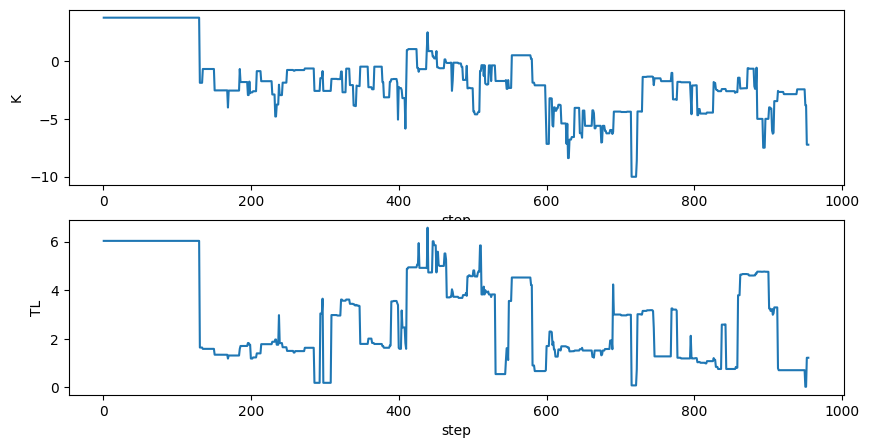

walker3.log
136


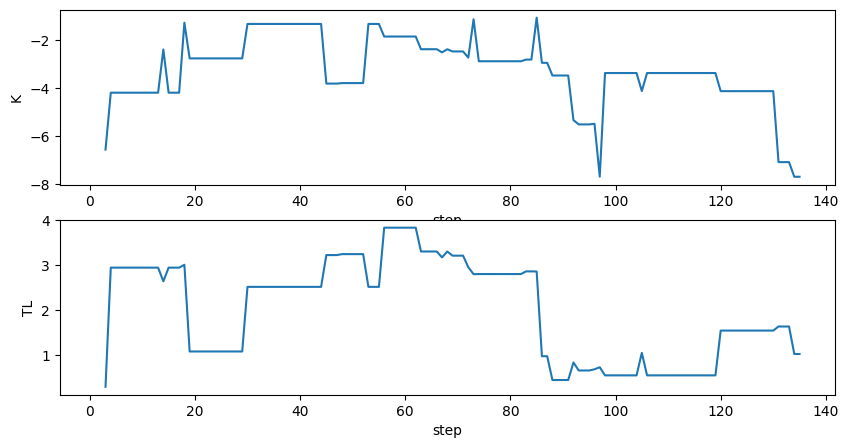

walker2.log
2465


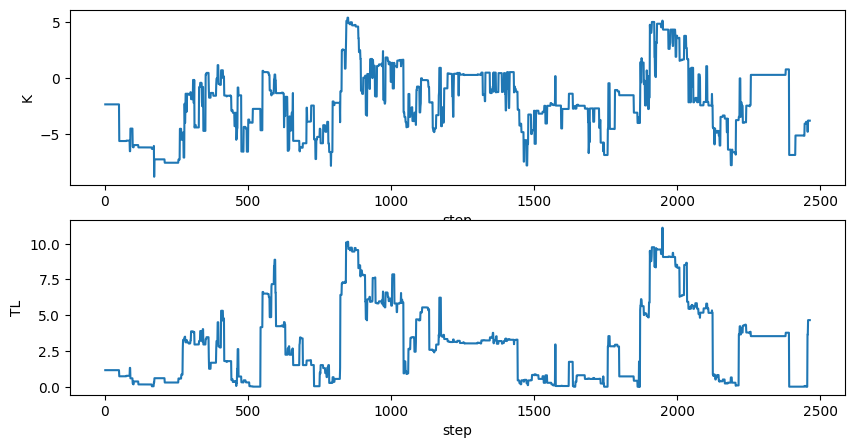

walker6.log
1402


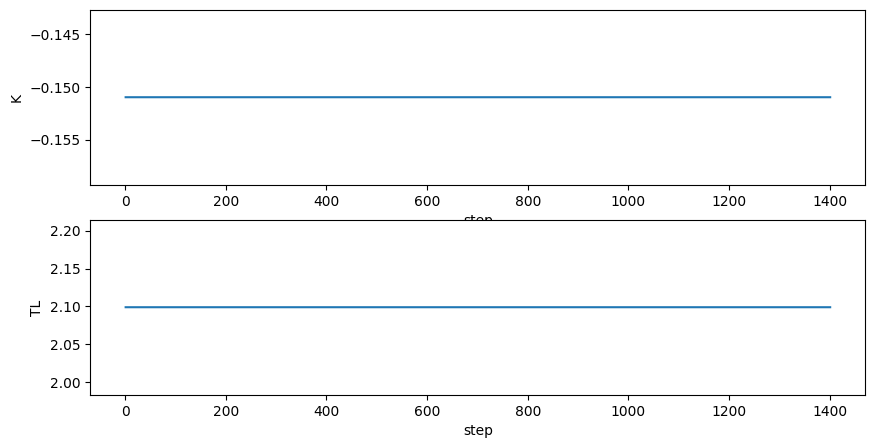

walker7.log
10000


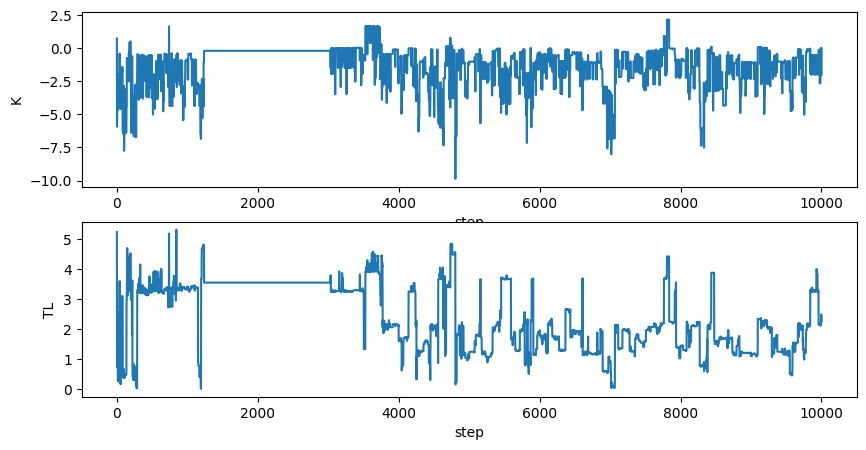

walker5.log
3471


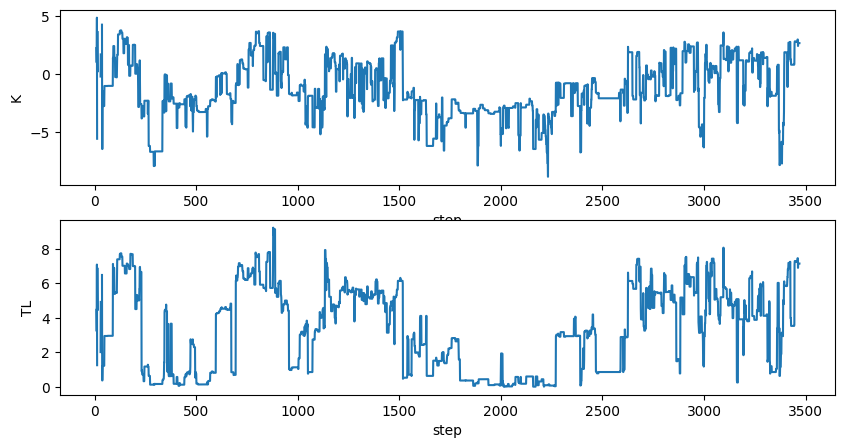

walker4.log
3950


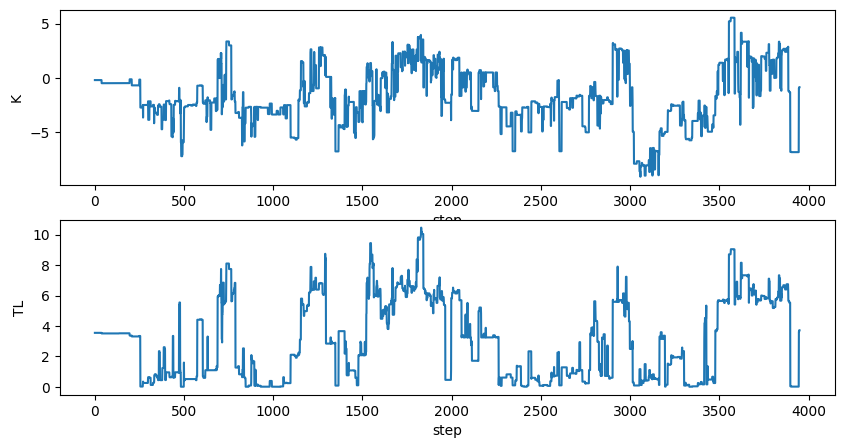

walker19.log
1823


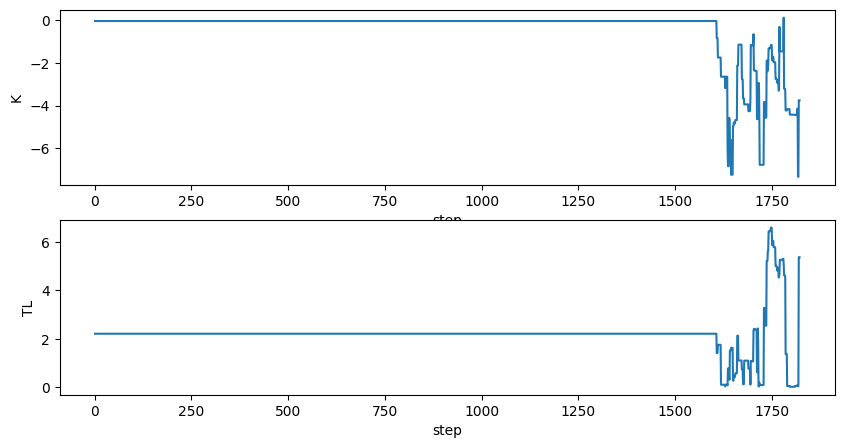

walker25.log
773


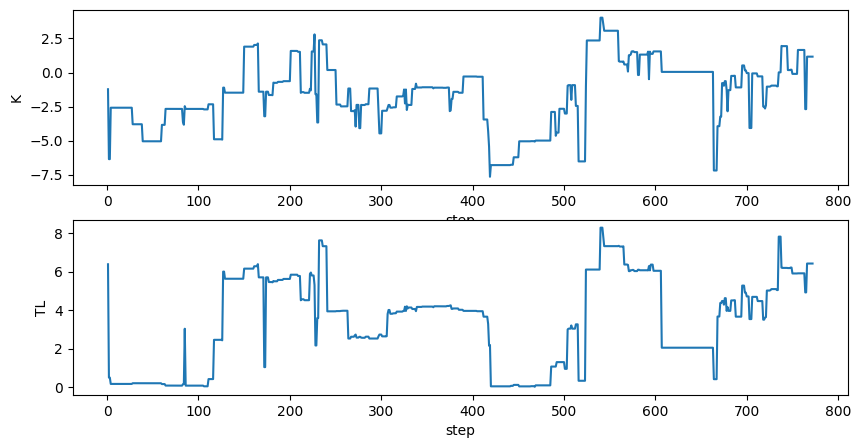

walker24.log
393


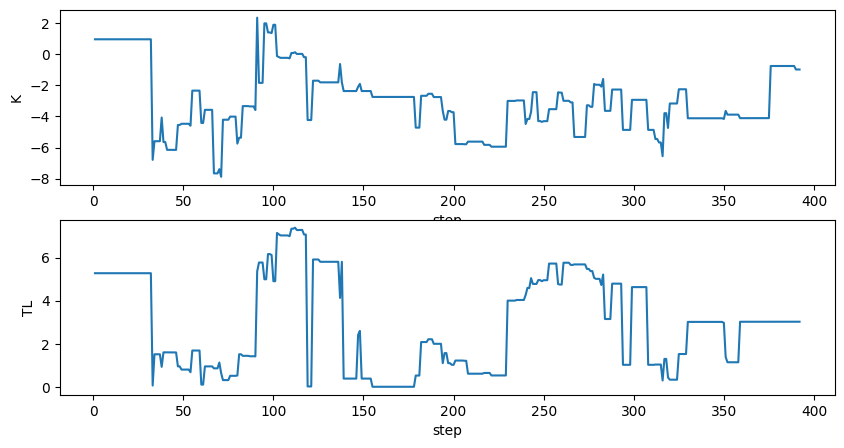

walker18.log
895


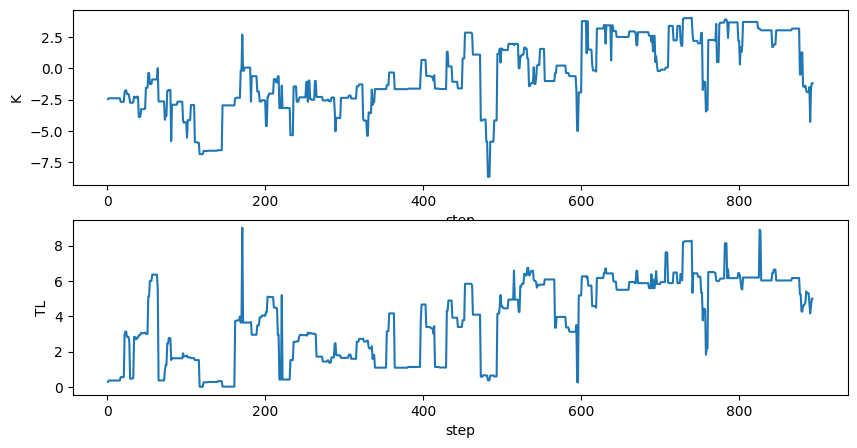

walker23.log
4704


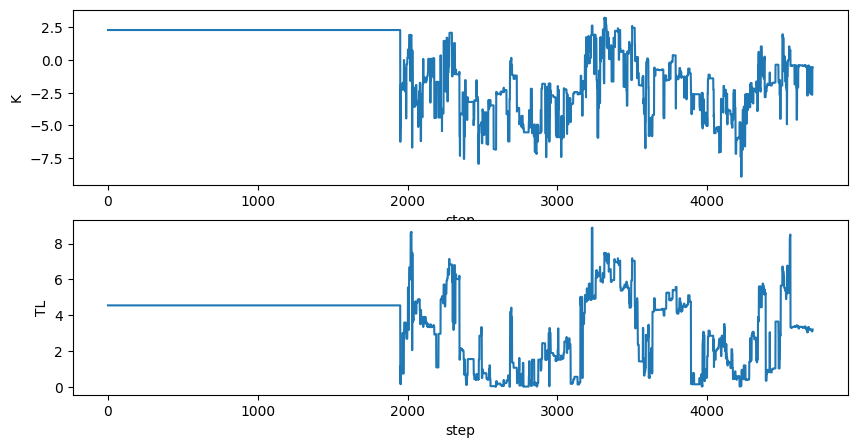

walker22.log
617


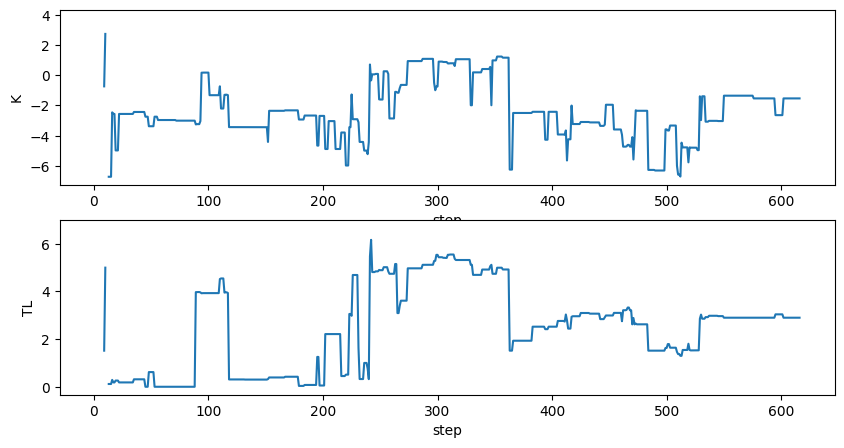

walker20.log
2776


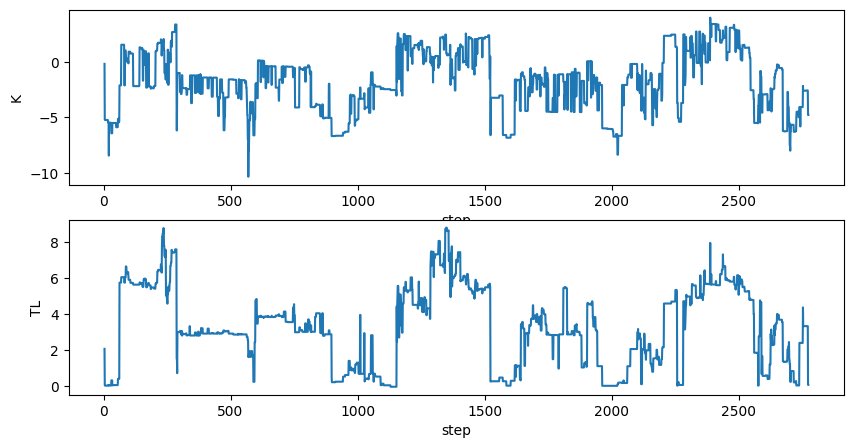

walker21.log
5654


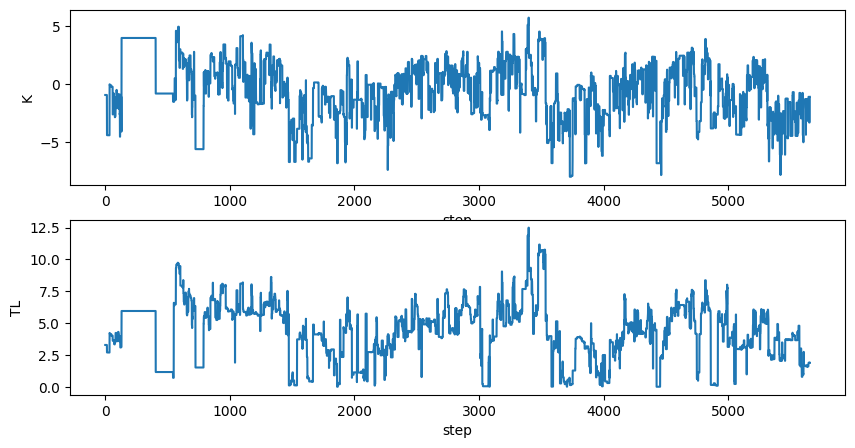

walker10.log
8072


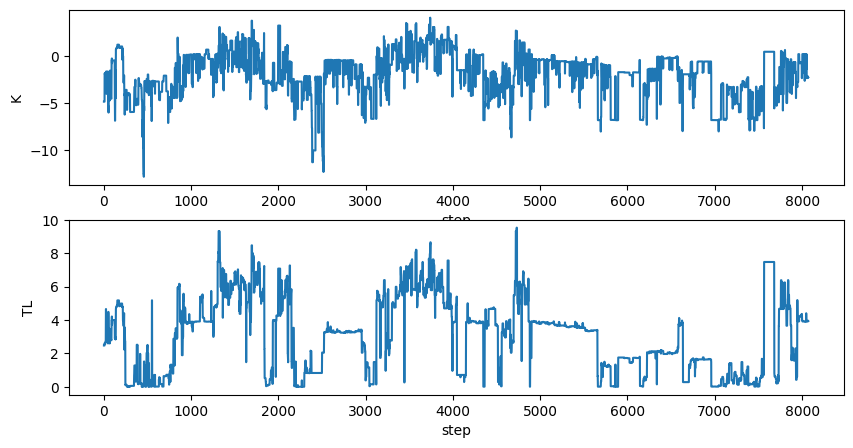

walker11.log
10000


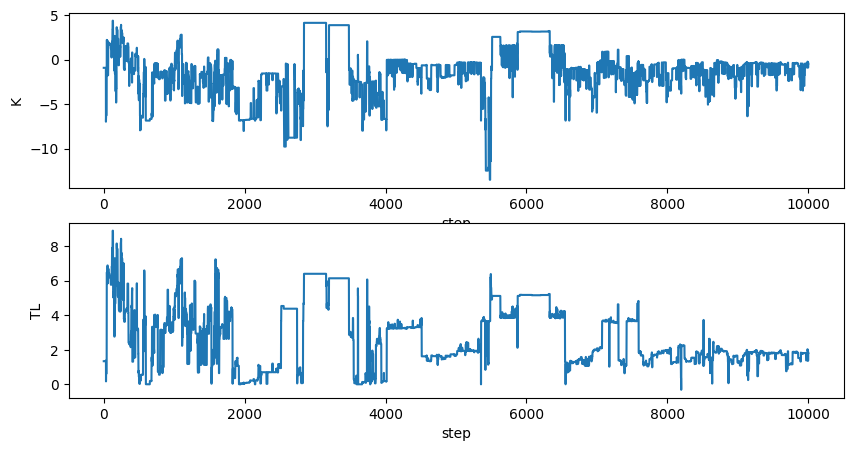

walker13.log
4296


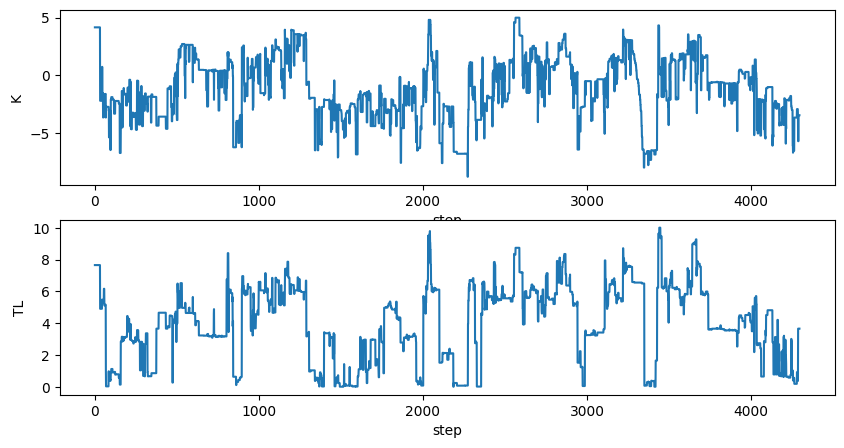

walker12.log
10000


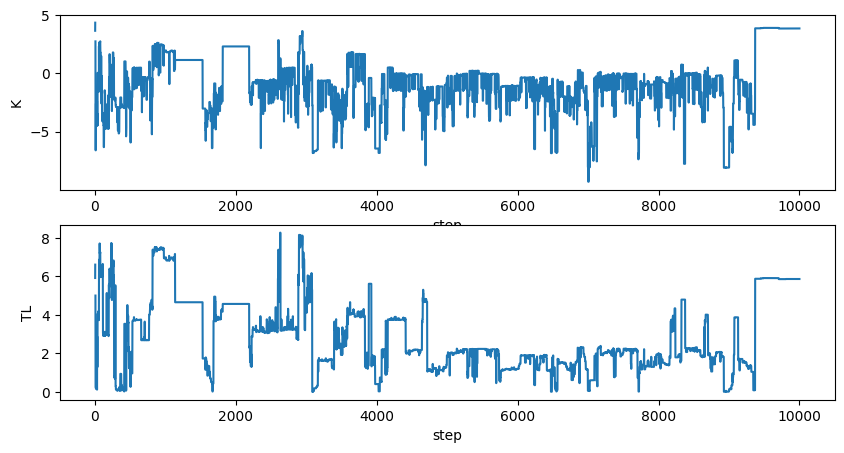

walker16.log
5466


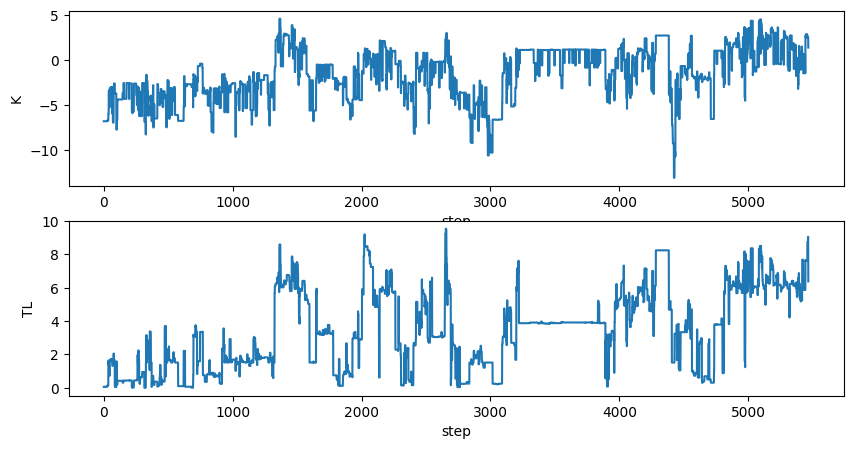

walker17.log
7026


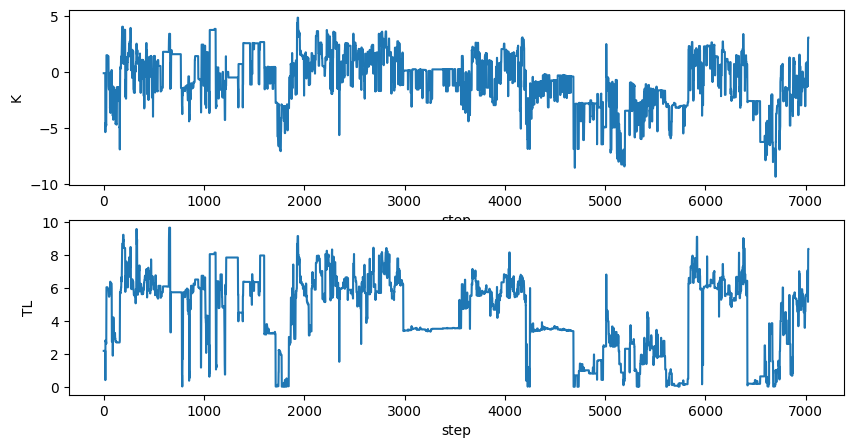

walker15.log
973


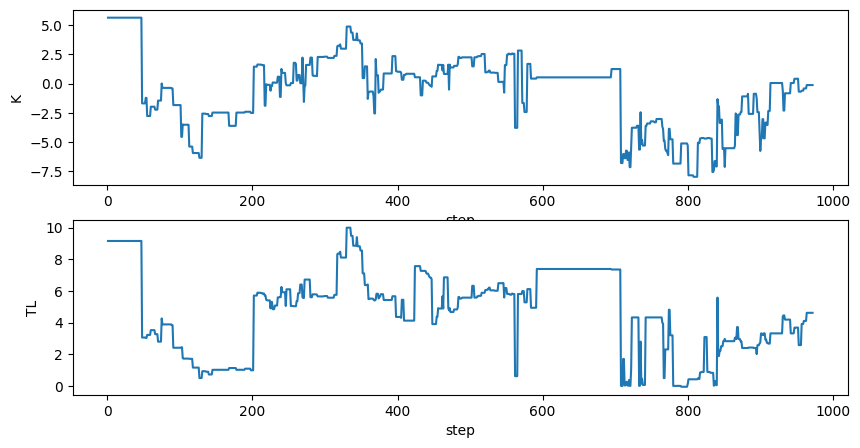

walker14.log
5086


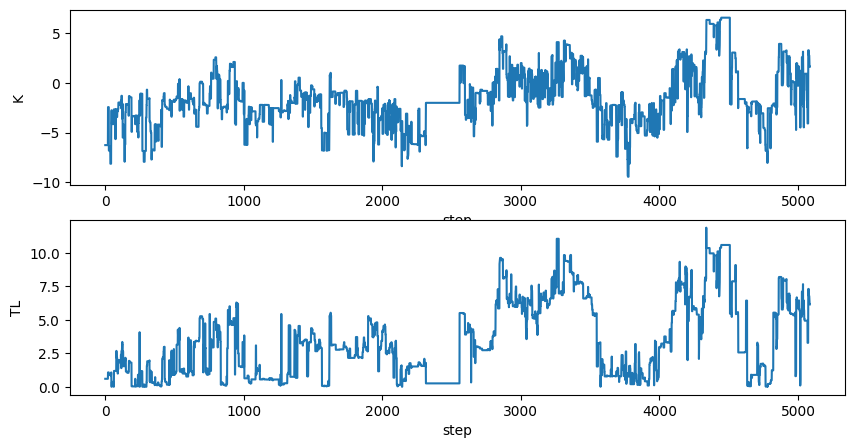

walker9.log
696


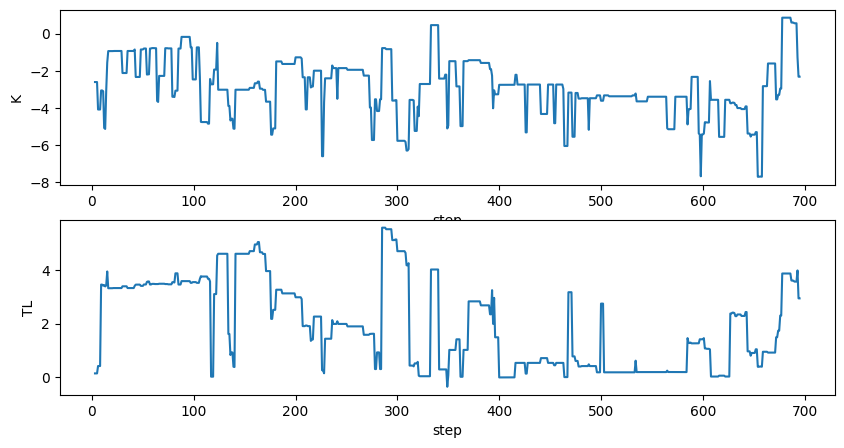

walker8.log
10000


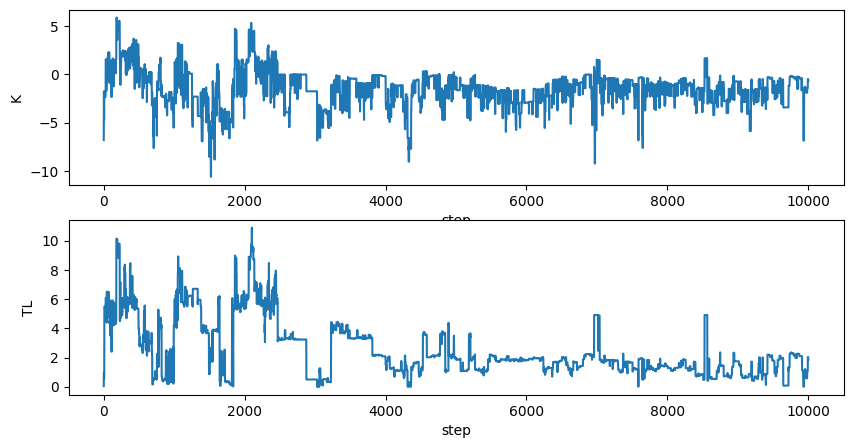

In [16]:
for i,file in enumerate(log_file):
    #if i==24:
    filename = file.split('/')[-1]
    print(f"{filename}")
    step_list, muhat_list, proto_list,accratio_list = read_log_file(file)
    print(len(step_list))
    K_list = get_all_proto(step_list, proto_list)

#plot_num_of_par(step_list, proto_list, K_list)

walker1.log


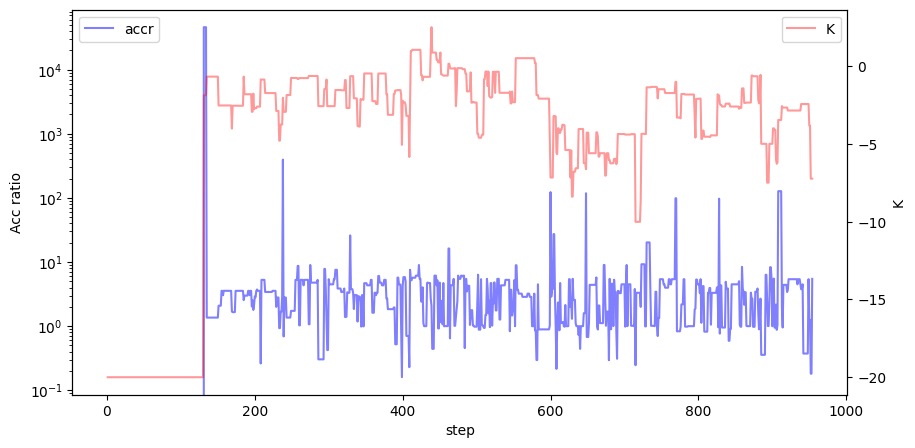

walker3.log


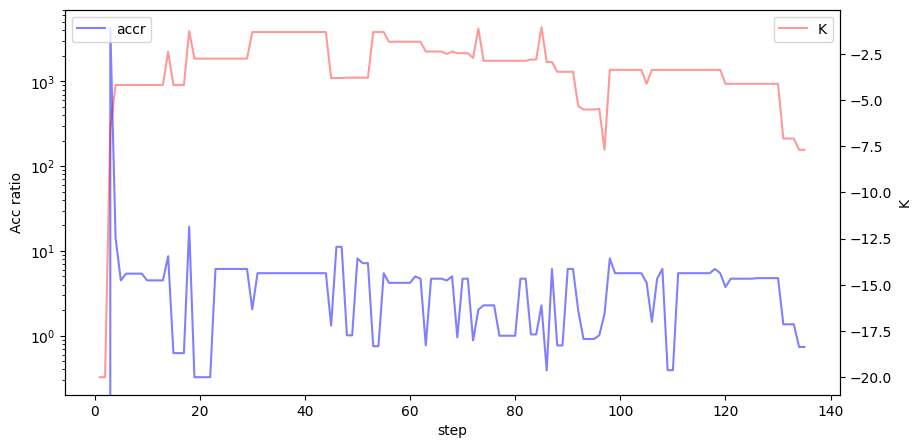

walker2.log


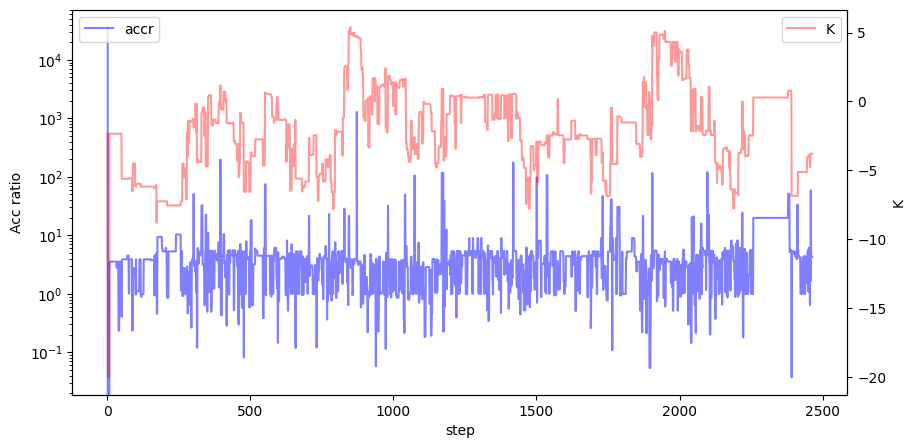

walker6.log
[107730.22377499667, 15373022.162401509, 1097304.6575062003, 366383.801936261, 380118.5353438643, 100215.17055123104, 785867.7266831365, 1279872.8210225215, 785867.7274653328, 0.0, 107730.22371375913, 10.581577241239268, 20836.22759437157, 139061.73312201494, 6906128.290257057, 88506.24180560454, 107730.22377499667, 104214.48605536387, 74843.65371301984, 1049.9540522029808, 346163.1123933768, 778173.375157965, 791061.5885619489, 15255.481132340263, 0.0, 777559.0835271621, 763453.9404341242, 162151.074338802, 56957.32278825174, 107730.22376274917, 20649.803496543034, 145537.3971929621, 44730.98402634574, 55698.473899295765, 408681.5180960967, 4.900727417979052, 398648.7715468383, 413289.3092331073, 785867.7274653328, 58978.02561200274, 389448.8019672422, 14191.177033196805, 151122.3068144126, 421666.31909604766, 12202227.2631668, 1526352.1842915455, 101939.52544011103, 757790.6501678246, 18.109808414081595, 419047.29550980777, 14005.420000019292, 107730.22376319008, 763150.0

/var/folders/w7/p4m7mfzs40s9kyhj0k95dxvh0000gn/T/ipykernel_8069/3347512850.py:133: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  print(f"non zeros {np.where(accr_list != 0)[0]}")


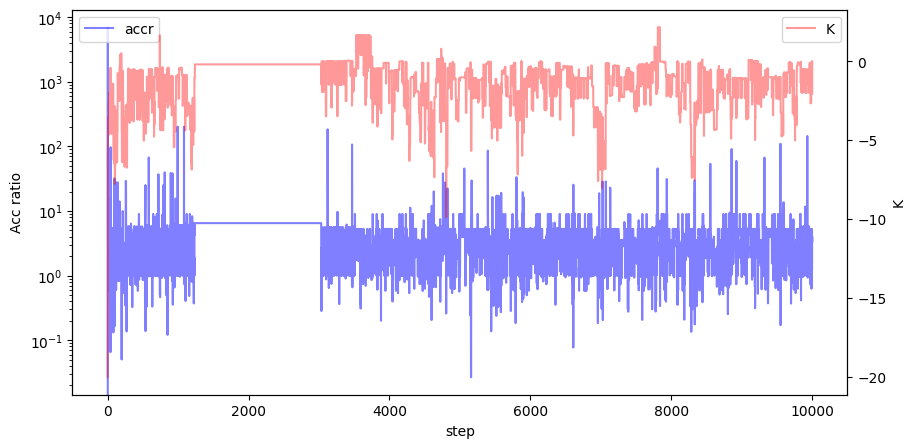

walker5.log


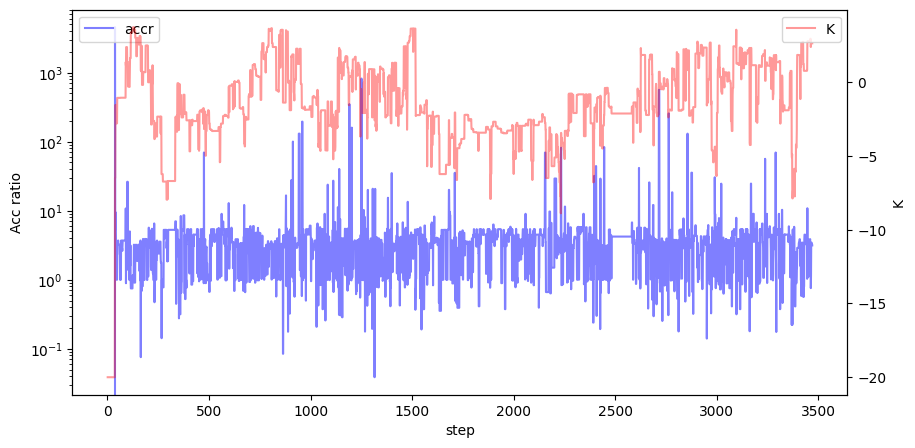

walker4.log


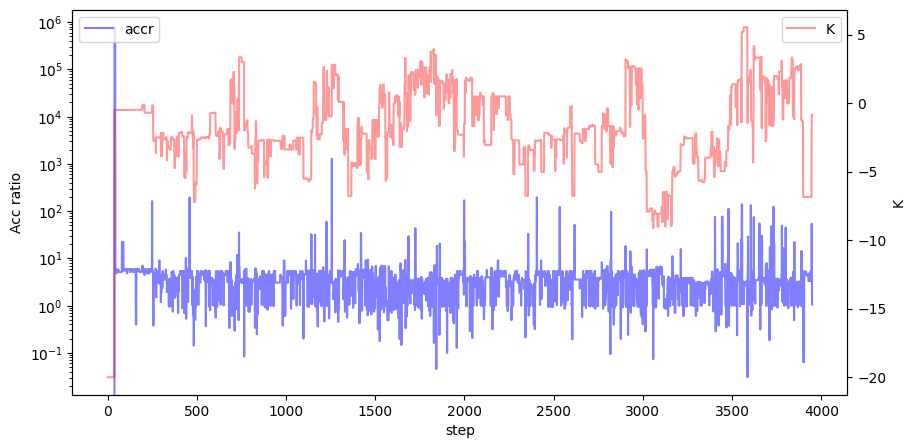

walker19.log


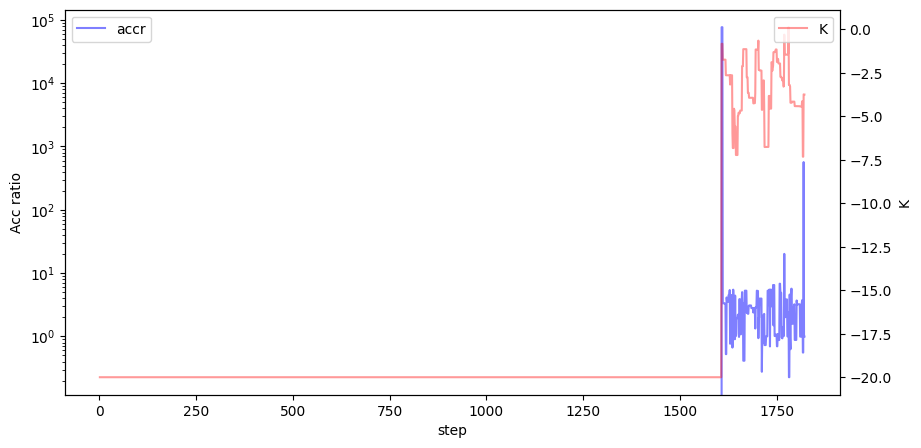

walker25.log


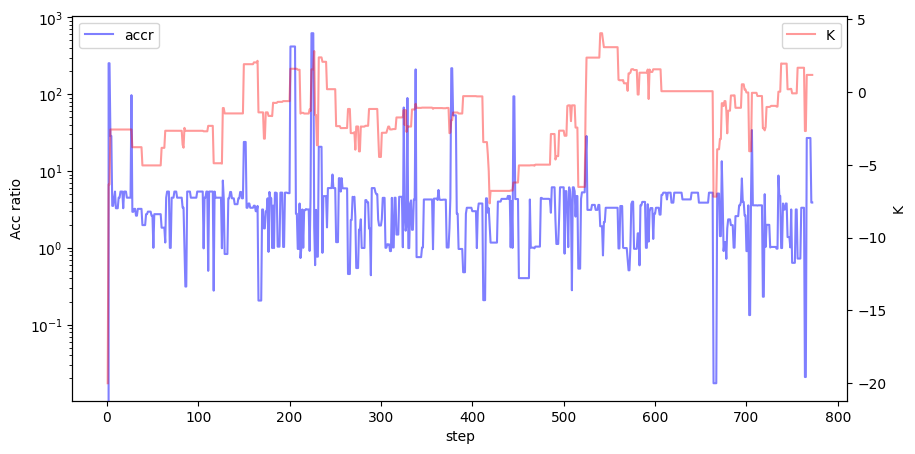

walker24.log


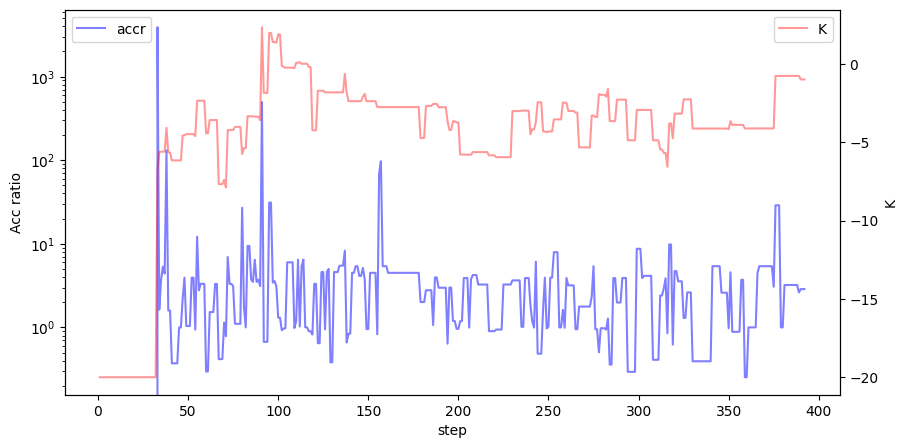

walker18.log


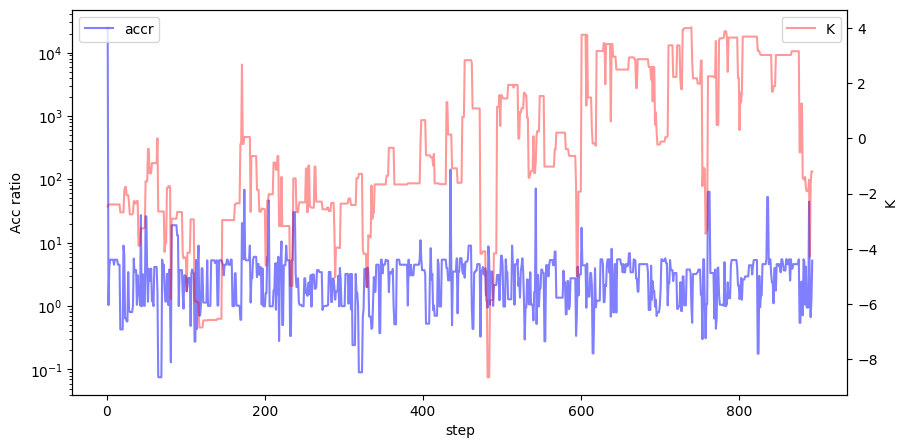

walker23.log


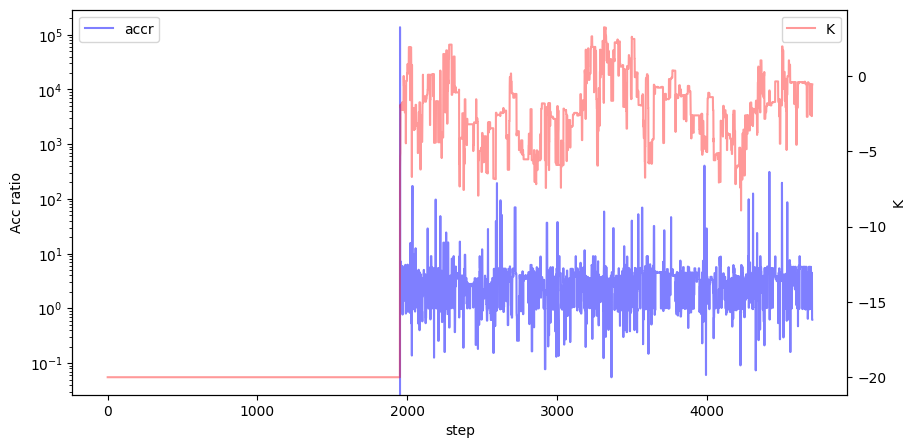

walker22.log


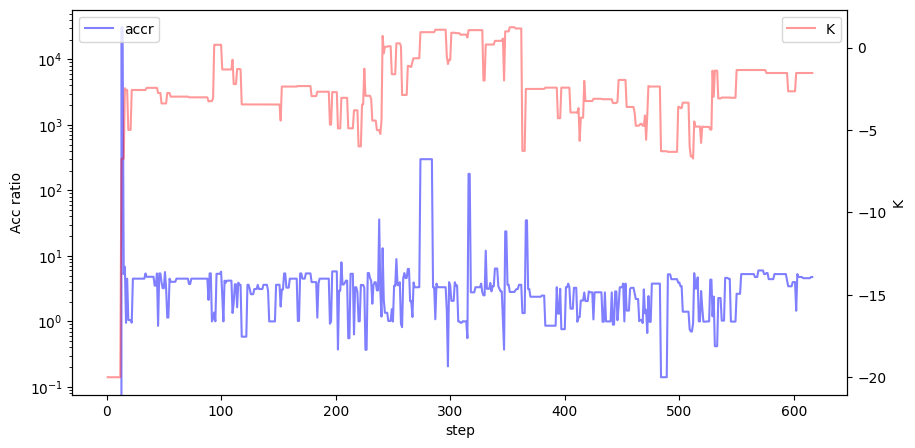

walker20.log


KeyboardInterrupt: 

In [100]:
for i,file in enumerate(log_file):
    filename = file.split('/')[-1]
    print(f"{filename}")
    step_list, muhat_list, proto_list,accratio_list = read_log_file(file)
    if i==3: print(accratio_list)
    plot_accratio(step_list, proto_list, accratio_list)


walker1


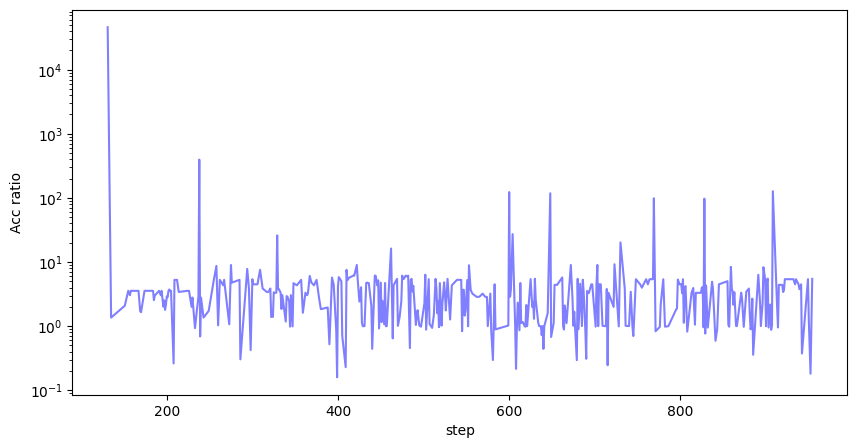

walker2


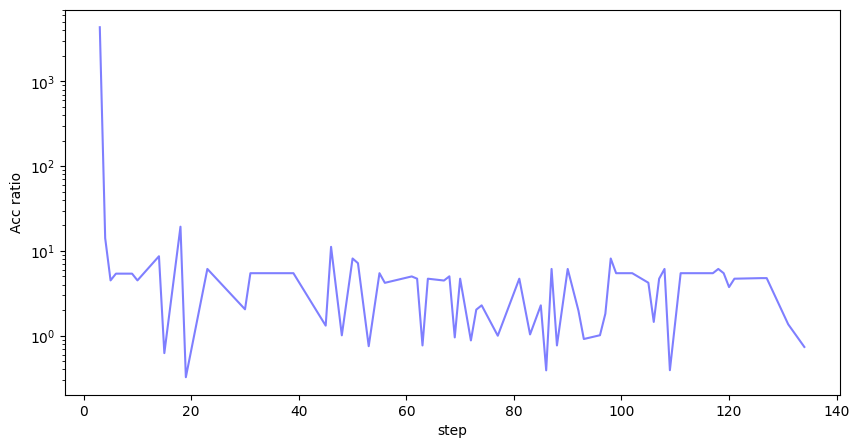

walker3


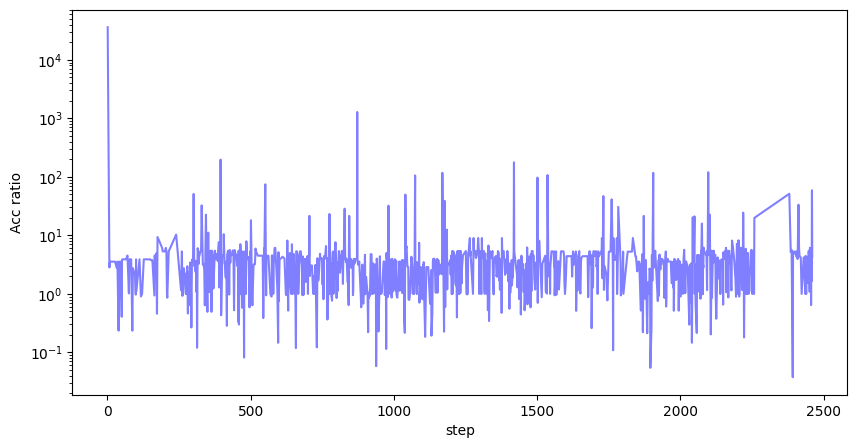

walker4


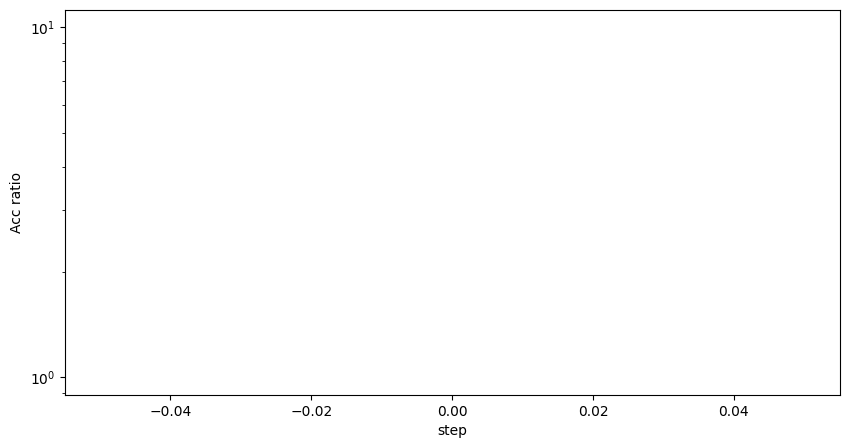

walker5


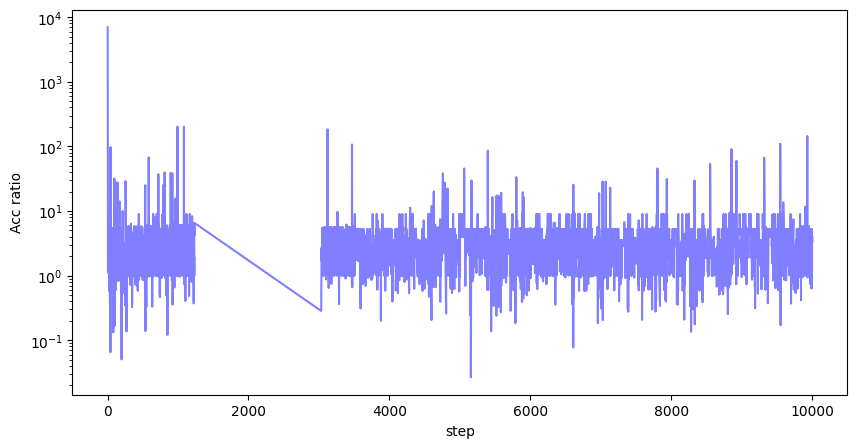

walker6


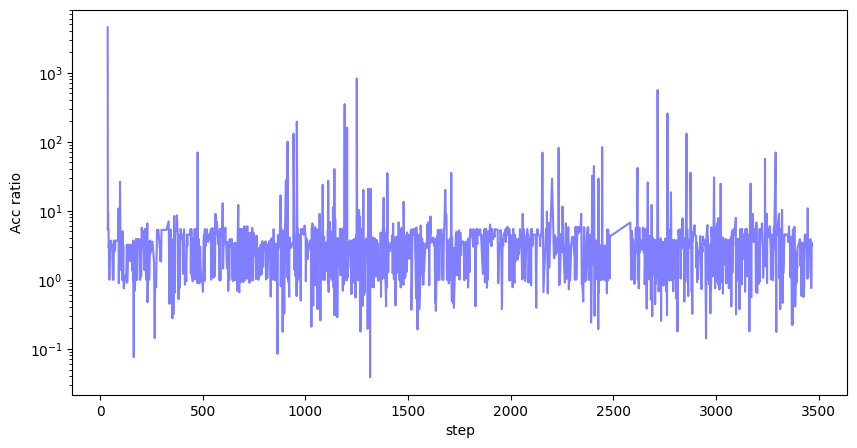

walker7


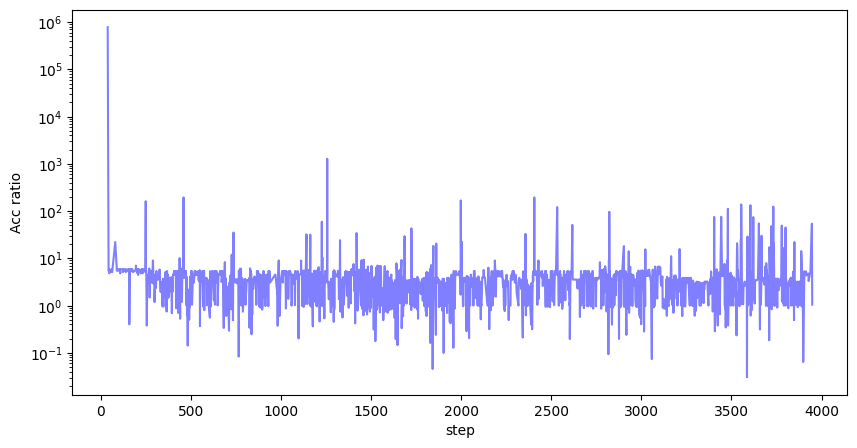

walker8


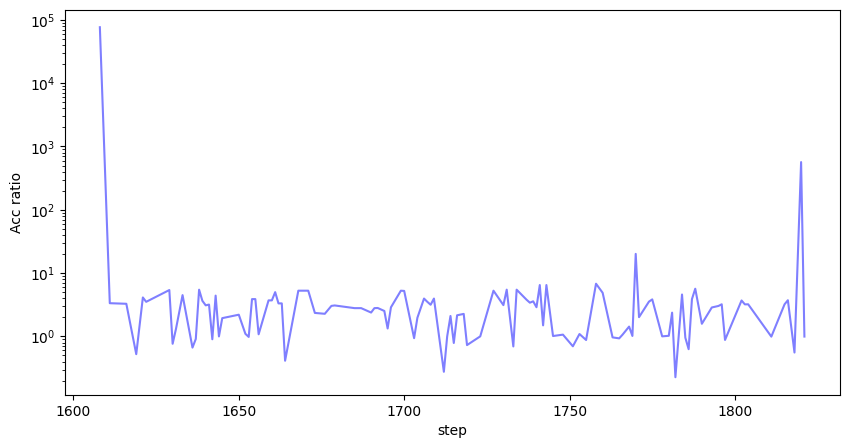

walker9


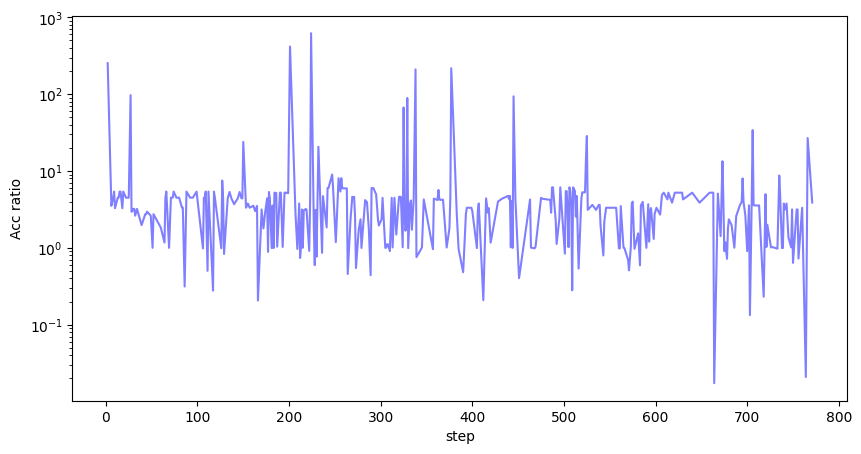

walker10


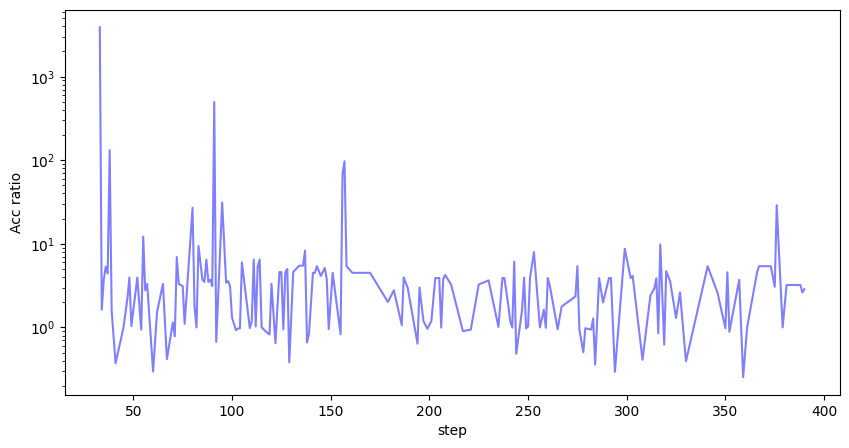

walker11


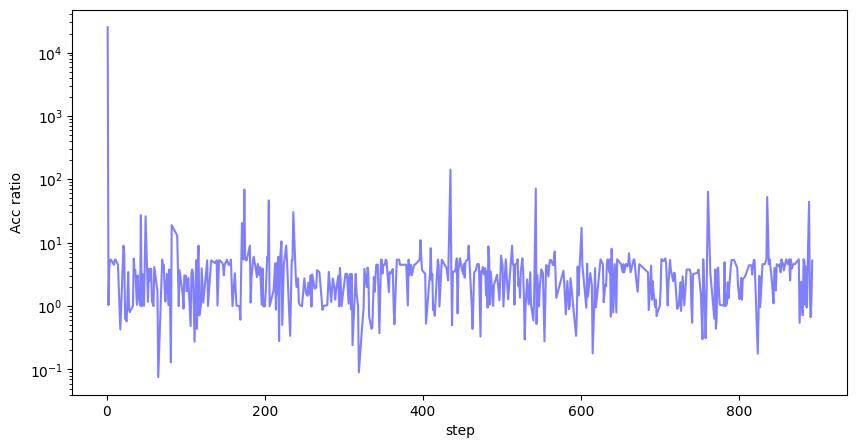

walker12


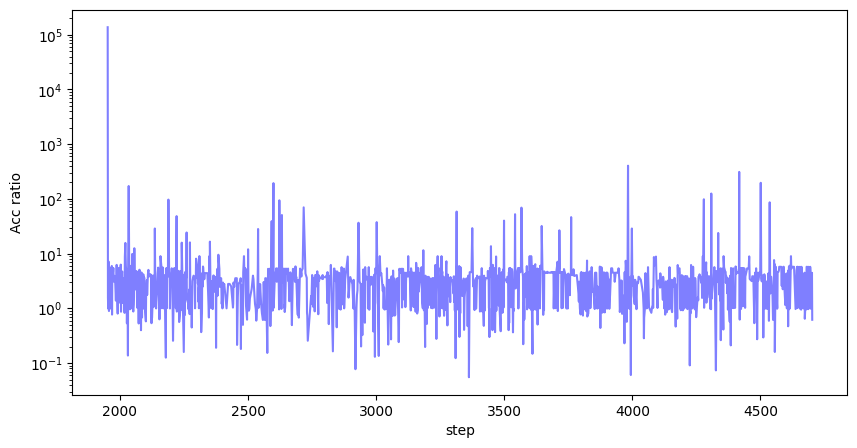

walker13


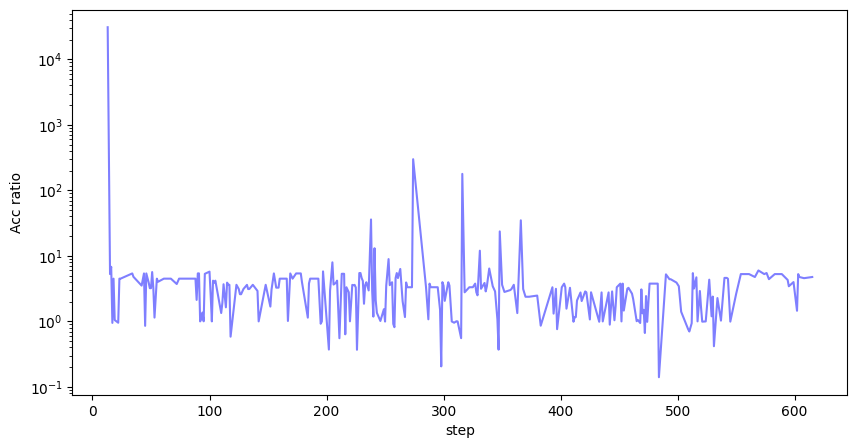

walker14


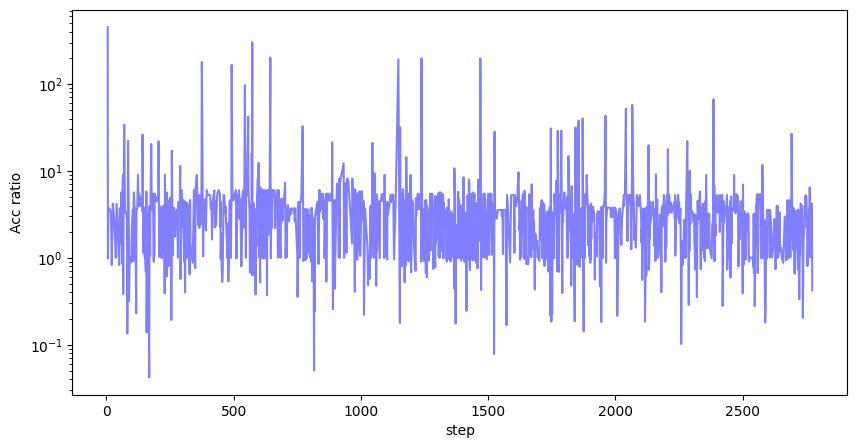

walker15


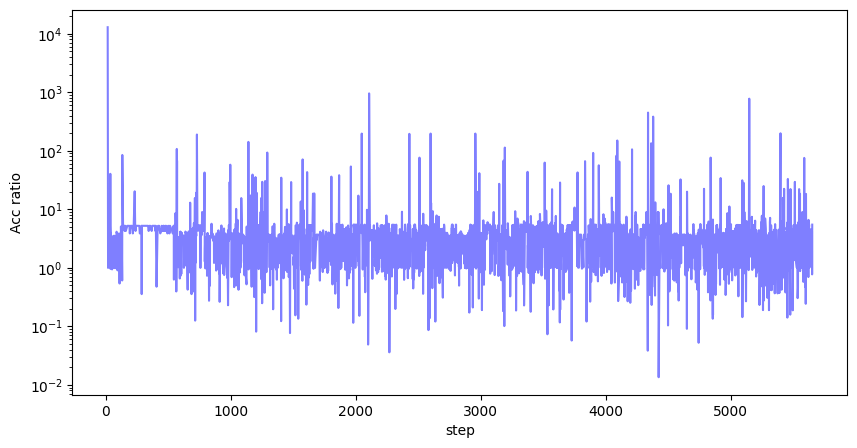

walker16


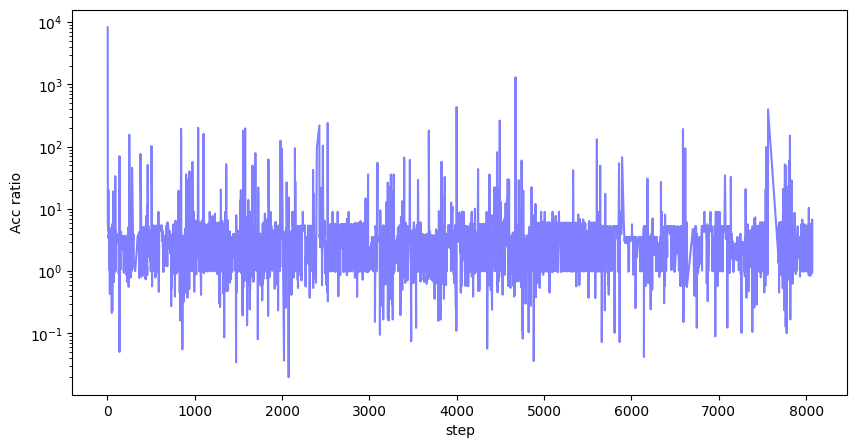

walker17


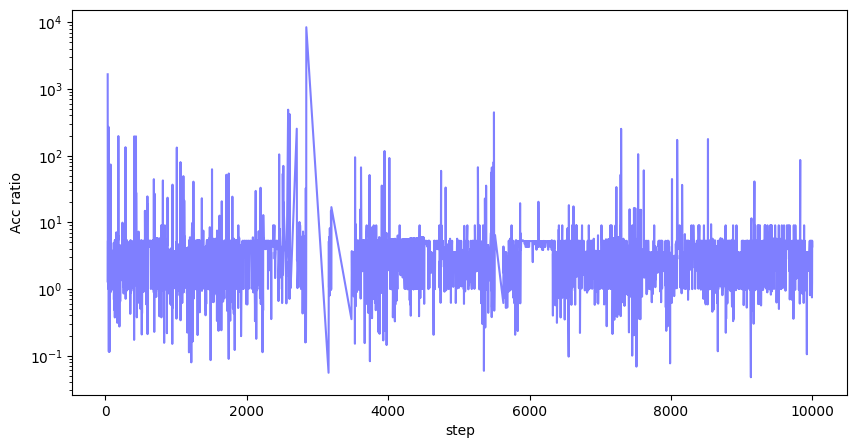

walker18


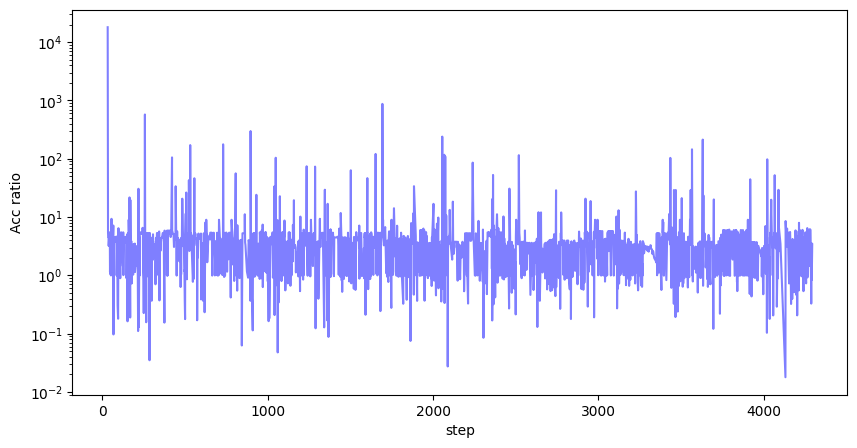

walker19


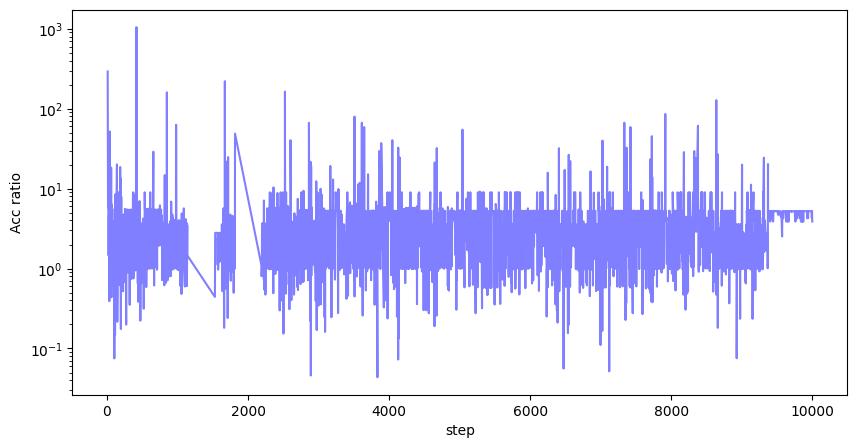

walker20


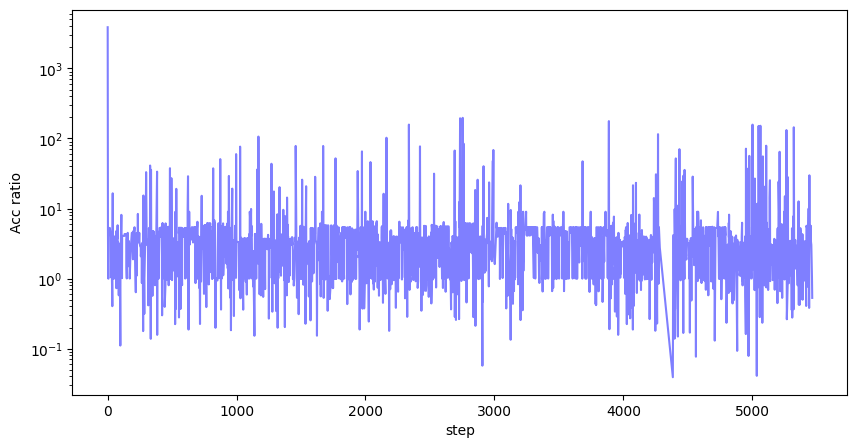

walker21


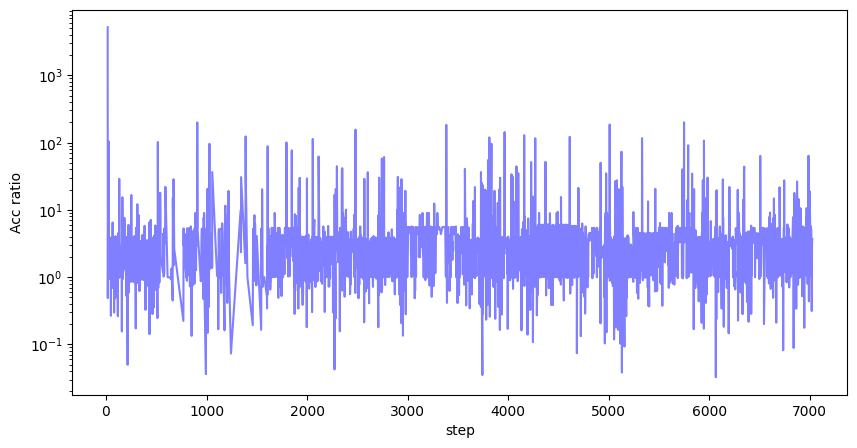

walker22


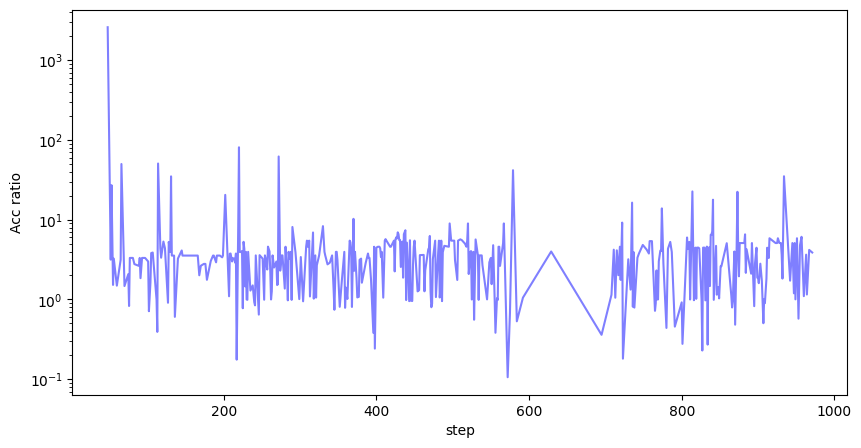

walker23


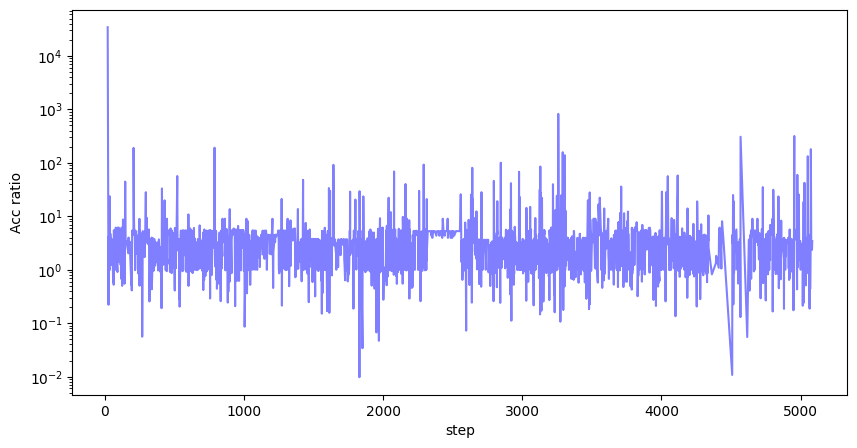

walker24


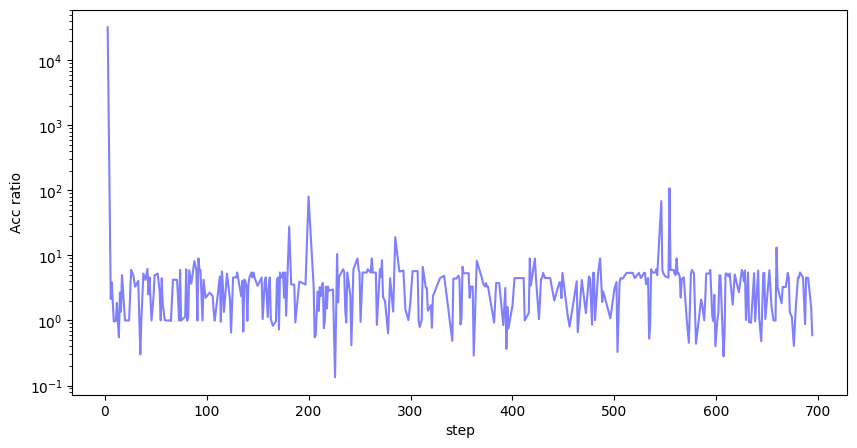

walker25


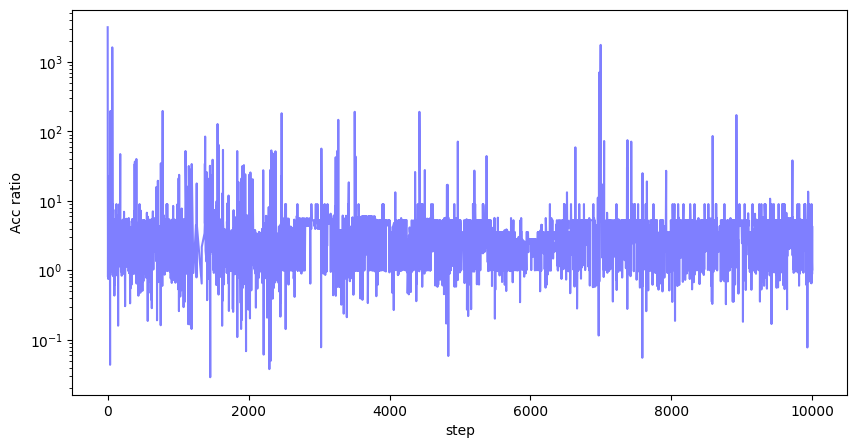

In [87]:
for i,file in enumerate(log_file):
    print(f"walker{i+1}")
    step_list, muhat_list, proto_list,accratio_list = read_log_file(file)
    #if i==3: print(accratio_list)
    plot_full_accratio(step_list, proto_list, accratio_list)

walker1.log
955


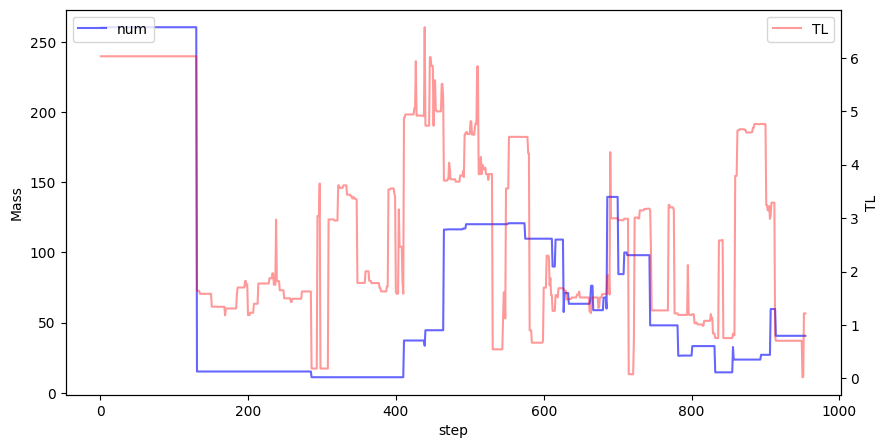

walker3.log
136


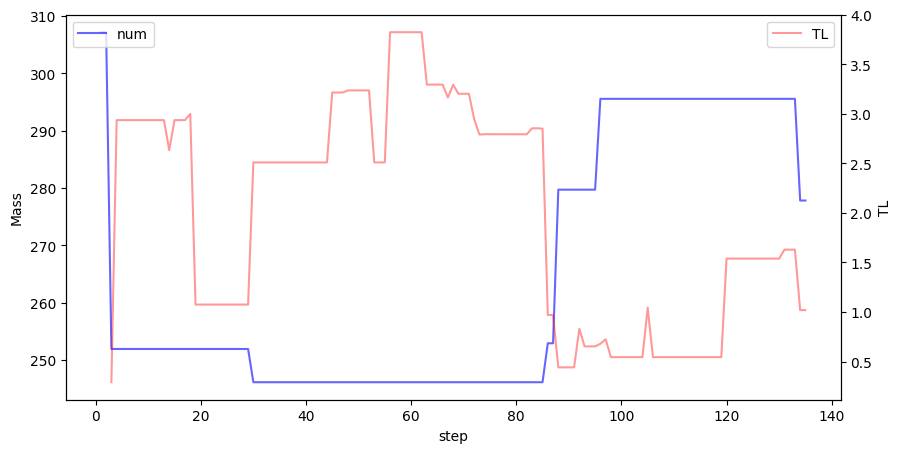

walker2.log
2465


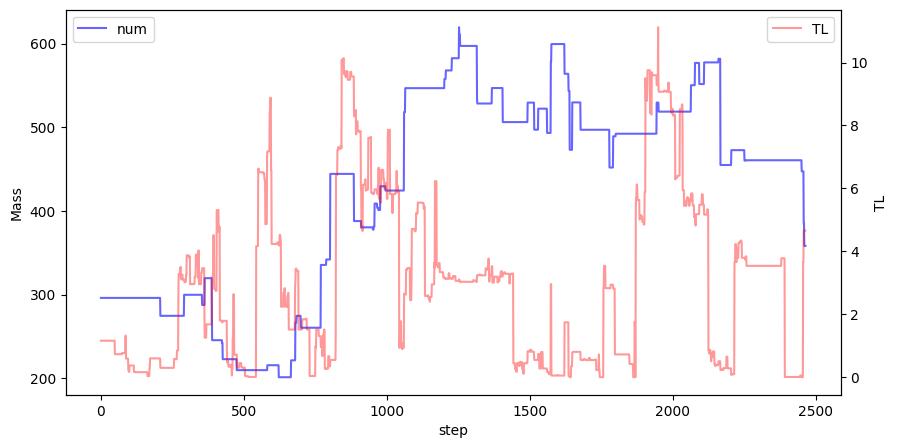

walker6.log
1402


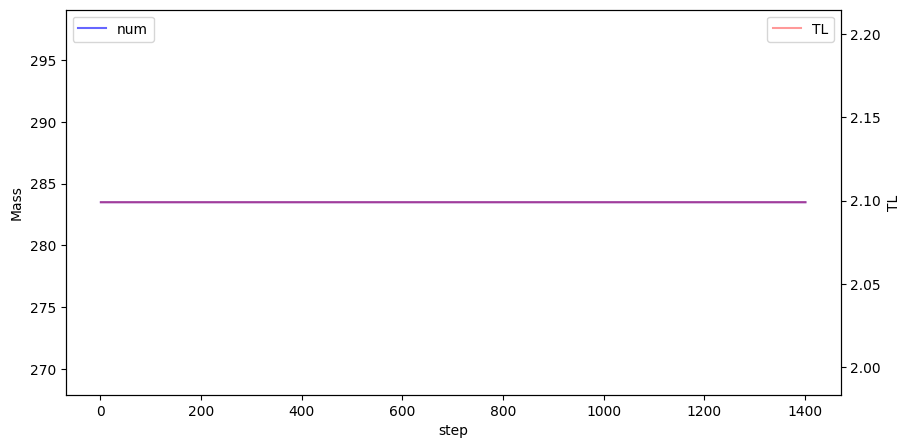

walker7.log
10000


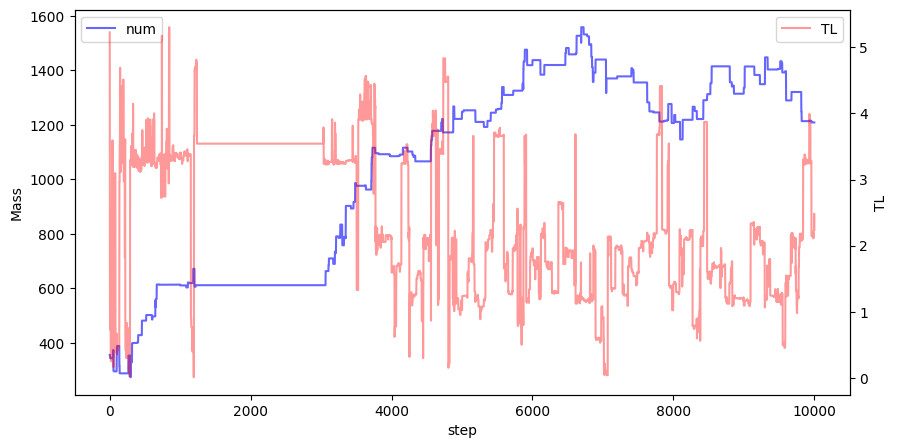

walker5.log
3471


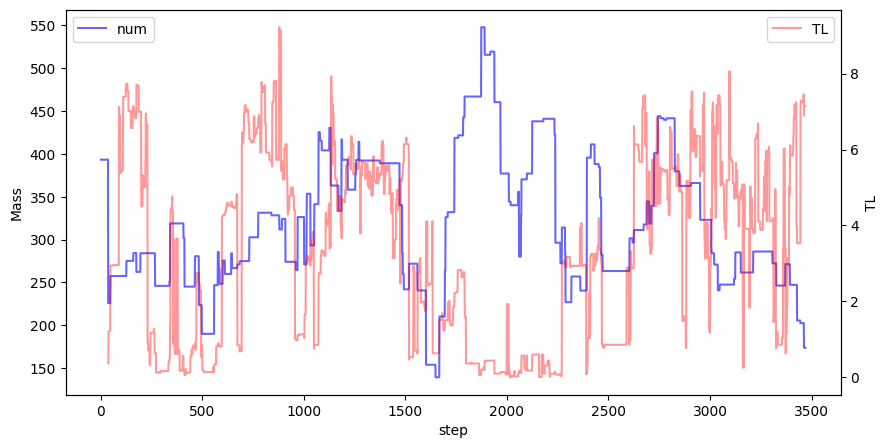

walker4.log
3950


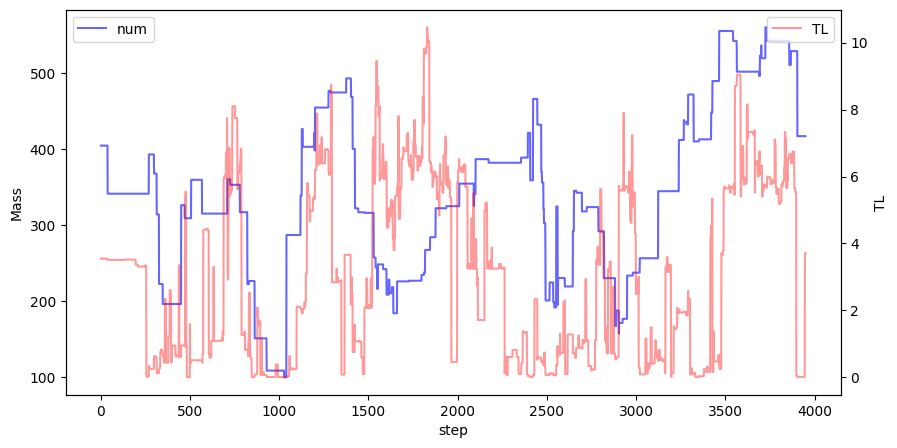

walker19.log
1823


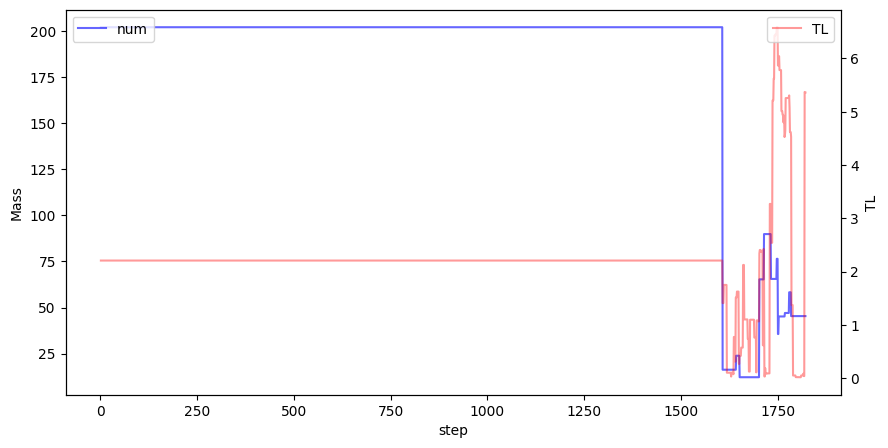

walker25.log
773


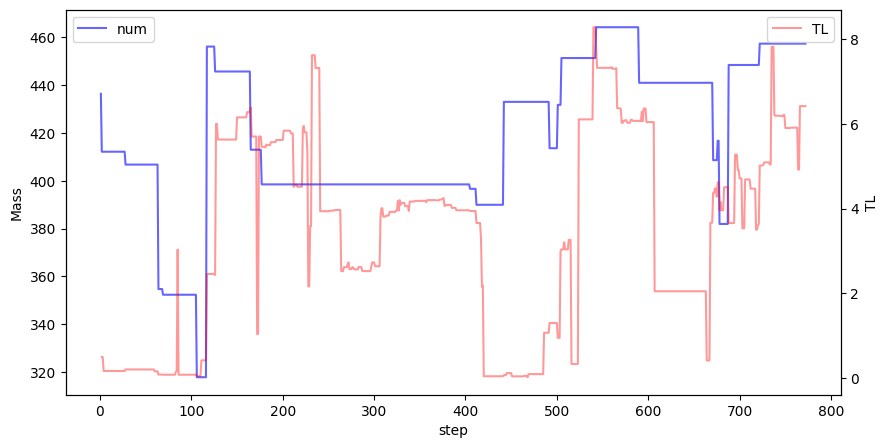

walker24.log
393


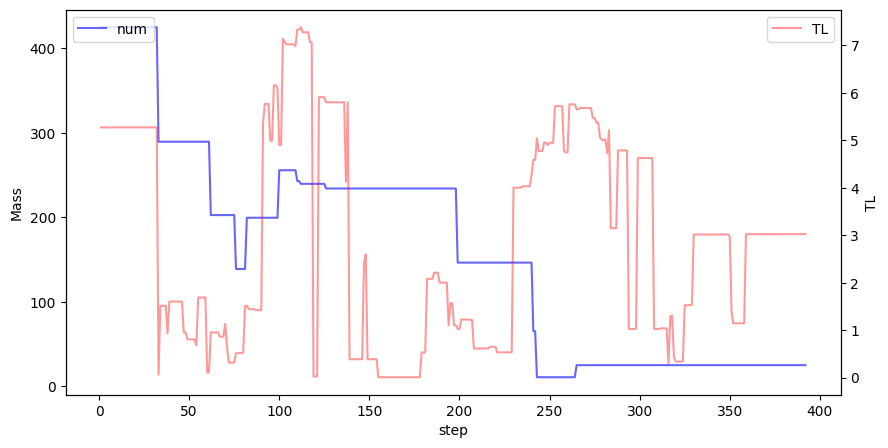

walker18.log
895


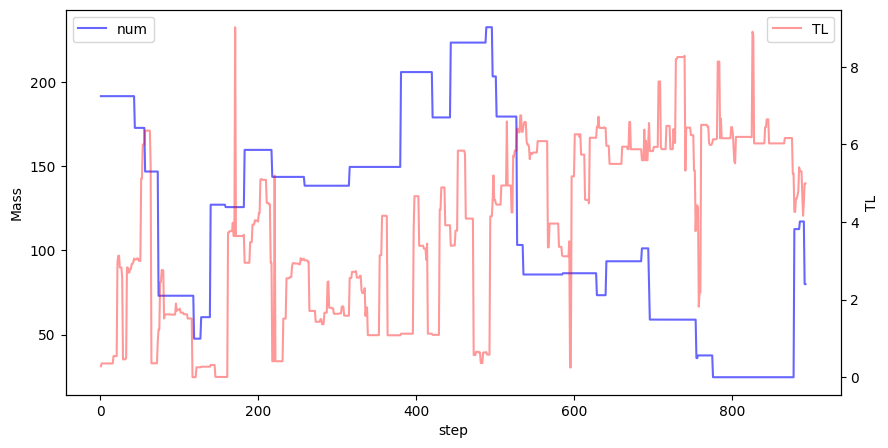

walker23.log
4704


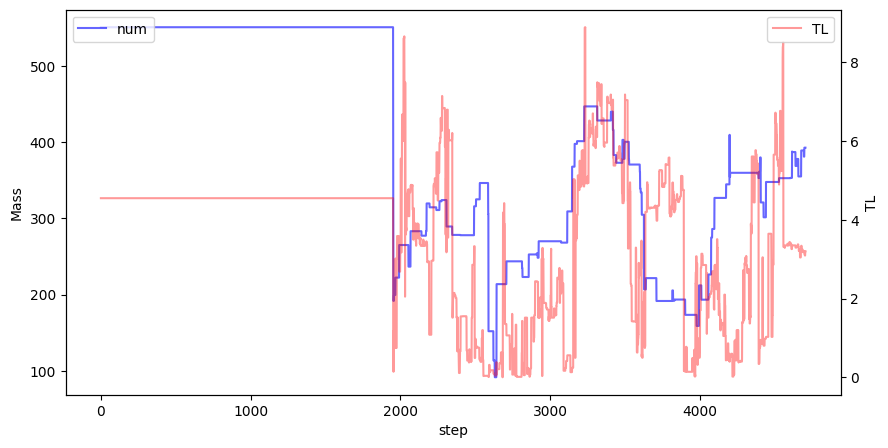

walker22.log
617


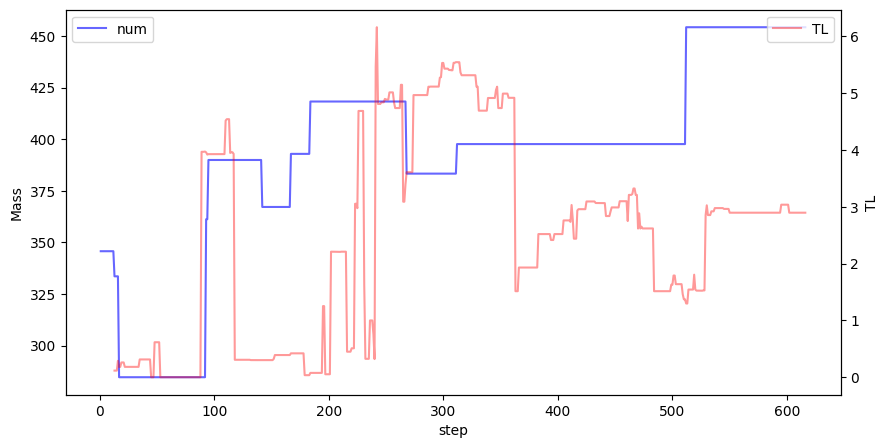

walker20.log
2776


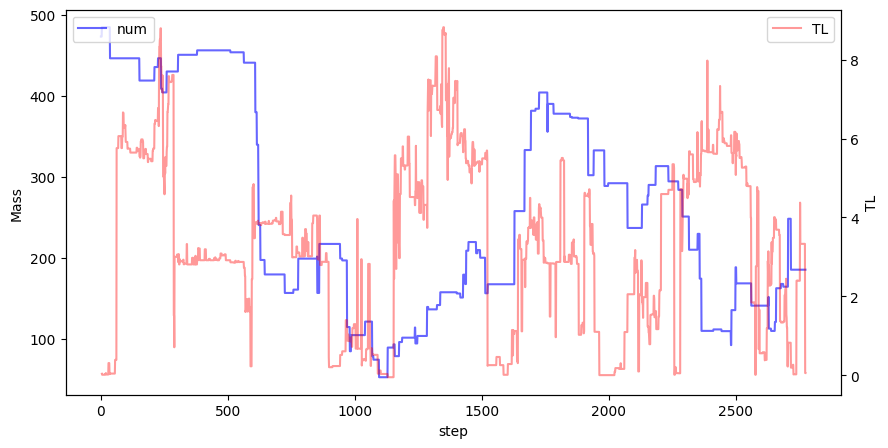

walker21.log
5654


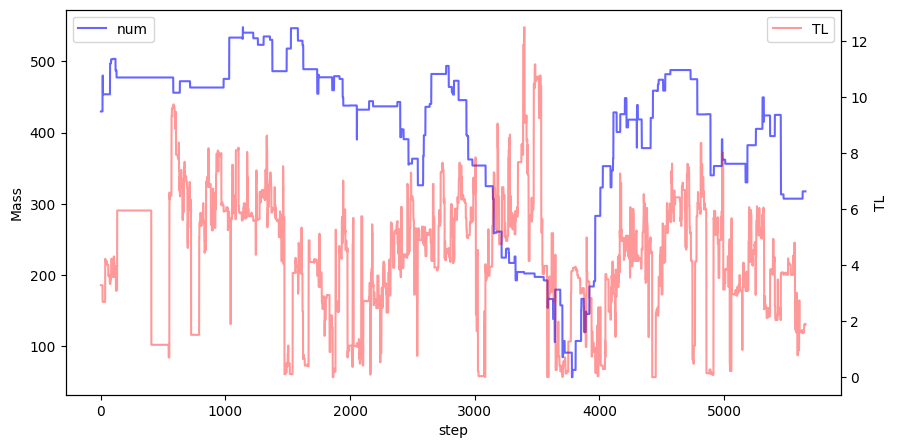

walker10.log
8072


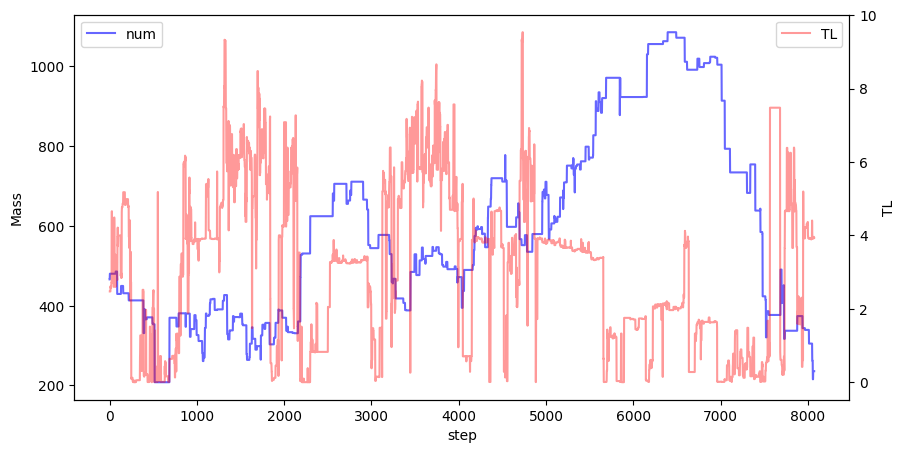

walker11.log
10000


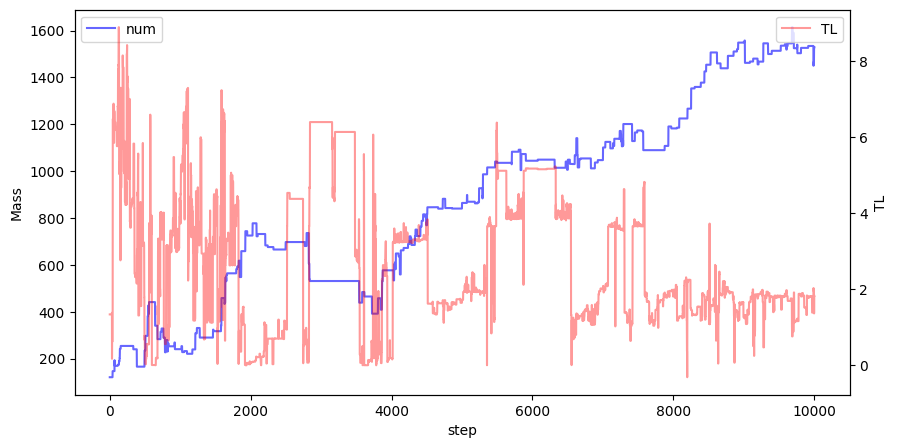

walker13.log
4296


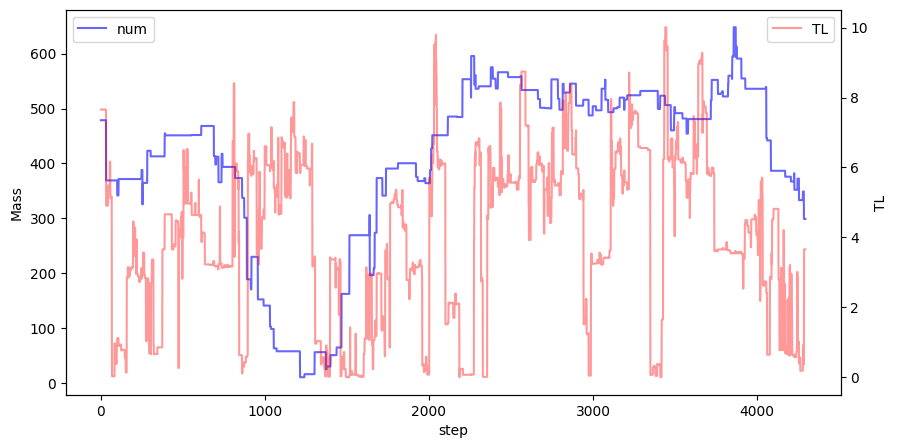

walker12.log
10000


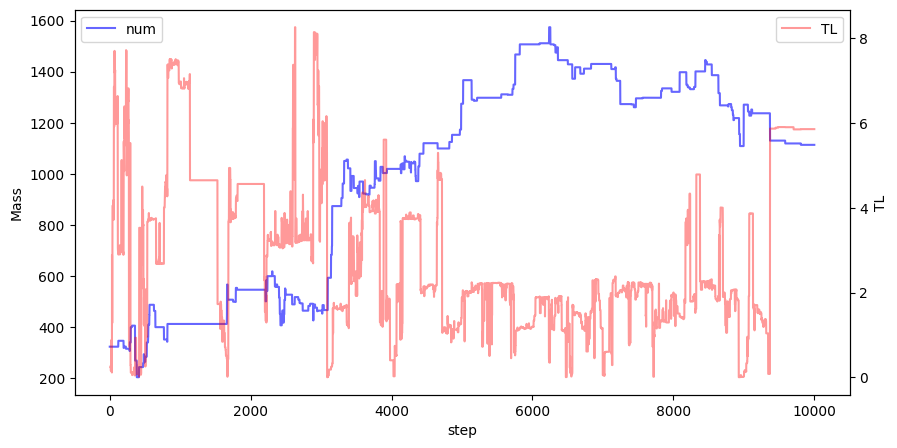

walker16.log
5466


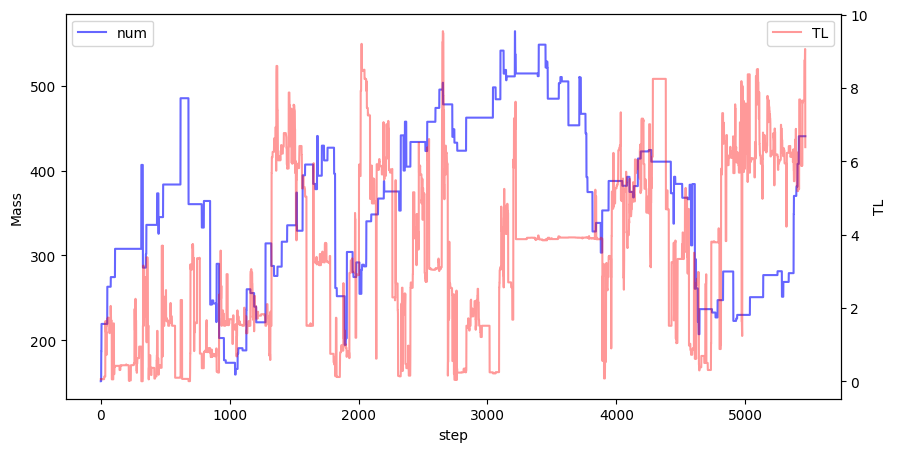

walker17.log
7026


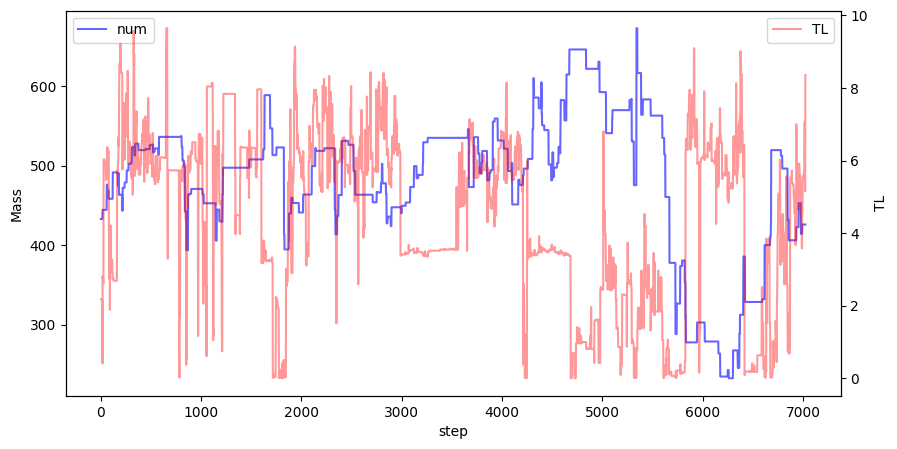

walker15.log
973


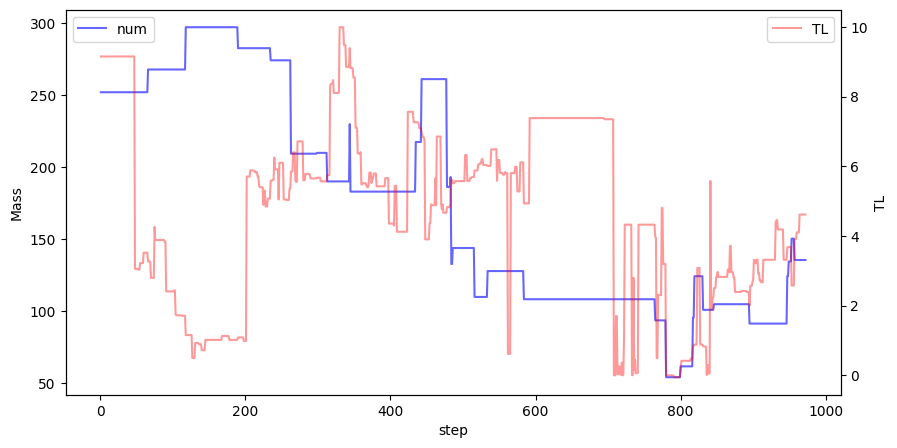

walker14.log
5086


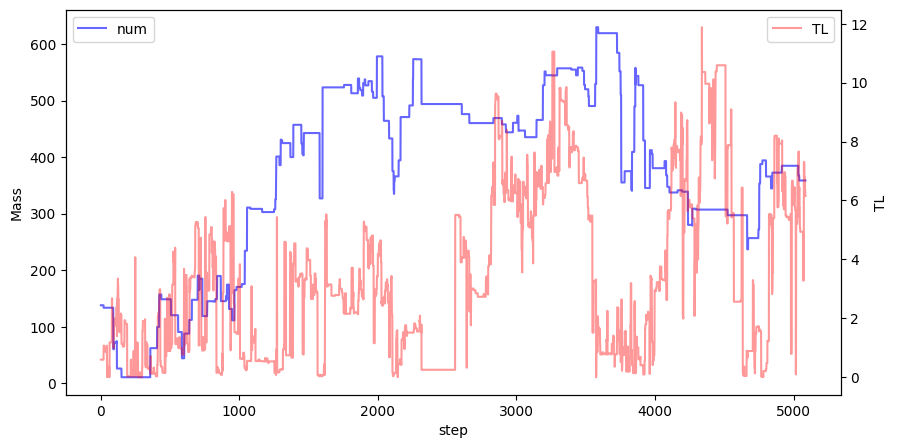

walker9.log
696


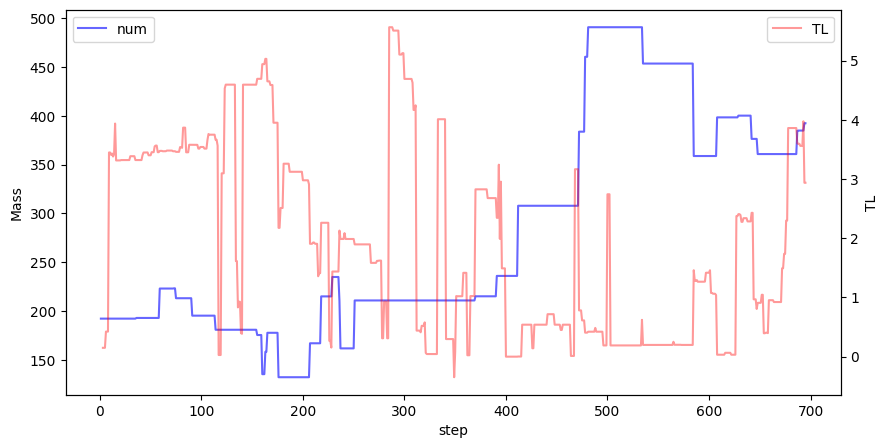

walker8.log
10000


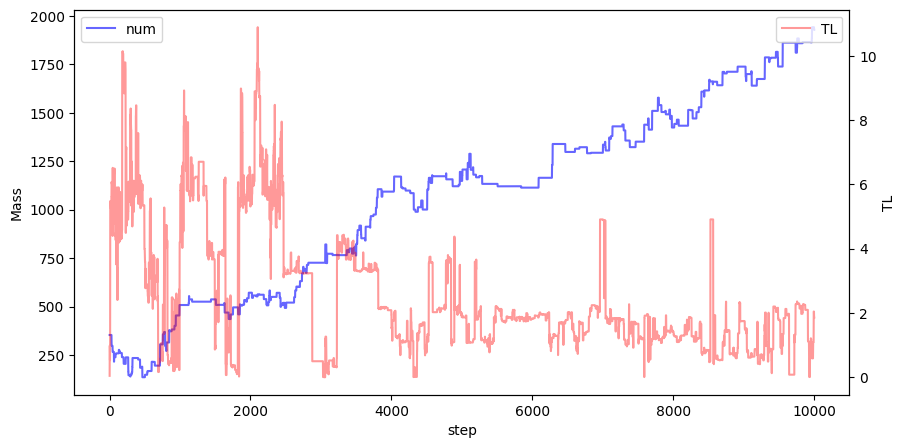

In [18]:
#plot_mass_of_lsp(step_list, proto_list)
for i,file in enumerate(log_file):
    #if i==24:
    filename = file.split('/')[-1]
    print(f"{filename}")
    step_list, muhat_list, proto_list, accratio_list = read_log_file(file)
    print(len(step_list))
    plot_mass_of_lsp(step_list, proto_list)
    #K_list = get_all_proto(step_list, proto_list)

In [ ]:
#get a trace plot for indices of accepted , get a short form of proto
#how to identify the burn-in phase?
#trace plot of acceptance ratio

In [167]:
brs = [0.6666666666666666, 0.1111111111111111, 0.1111111111111111, 0.1111111111111111]
dbr = max(np.max(brs)- np.mean(brs), np.mean(brs) - np.min(brs))

(1- dbr/3)

0.8611111111111112

In [21]:
par = [ 1000001, 1000002, 1000003, 1000004, 1000005, 1000006, 2000005, 2000006, 1000011, 1000012, 1000013, 1000014, 1000015,
        1000016, 1000021, 1000022, 1000023, 1000025, 1000024, 1000037 ]

forpar = [1000001, 1000002, 1000003, 1000004, 1000005, 1000006, 2000005, 2000006]

newpar = [p for p in par if p not in forpar]
print(newpar)

[1000011, 1000012, 1000013, 1000014, 1000015, 1000016, 1000021, 1000022, 1000023, 1000025, 1000024, 1000037]


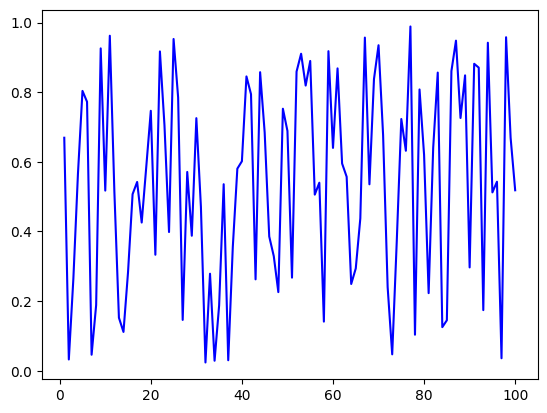

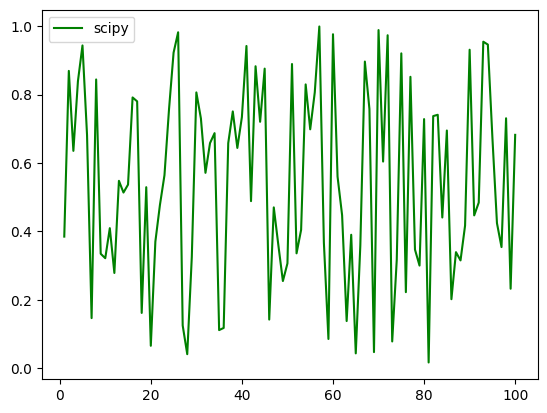

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
ulist, sulist, step_list = [],[],[]
for i in range(100):
    u = np.random.uniform(0,1)
    su = uniform.rvs(loc=0, scale=1, size=1)[0]
    ulist.append(u)
    sulist.append(su)
    step_list.append(i+1)


plt.plot(step_list, ulist, color='blue', label='numpy')
plt.show()
plt.plot(step_list, sulist, color='green', label='scipy')
plt.legend()
plt.show()

In [31]:
print(f"{sulist[0]:.2f}")
sulist[0] < 0.4

0.38


True